In [95]:
import os
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import seasonal_plot
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
from pysr import PySRRegressor

In [96]:
df = pd.read_csv('train.csv').sort_values('Date').reset_index(drop=True)
df.tail(10)

,Unnamed: 0,Date,FEDFUNDS,DTWEXBGS,GDPC1,CPIAUCSL,RTWEXBGS
63,63,2021-12-31,0.080000,114.966572,21988.737,278.771333,109.338667
64,64,2022-03-31,0.120000,115.490194,21932.710,284.905667,110.333167
65,65,2022-06-30,0.770000,118.963565,21967.045,291.605333,113.836933
66,66,2022-09-30,2.190000,123.528420,22125.625,295.453000,117.974000
67,67,2022-12-31,3.653333,124.812908,22278.345,298.541667,118.761933
68,68,2023-03-31,4.516667,120.309608,22439.607,301.230333,114.565067
69,69,2023-06-30,4.990000,119.396548,22580.499,303.397667,113.641533
70,70,2023-09-30,5.260000,119.850633,22840.989,305.989000,113.852400
71,71,2023-12-31,5.330000,121.549923,23033.780,308.195000,115.367333
72,72,2024-03-31,5.330000,120.644013,23082.119,311.003333,114.493533


# Провекра стац

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

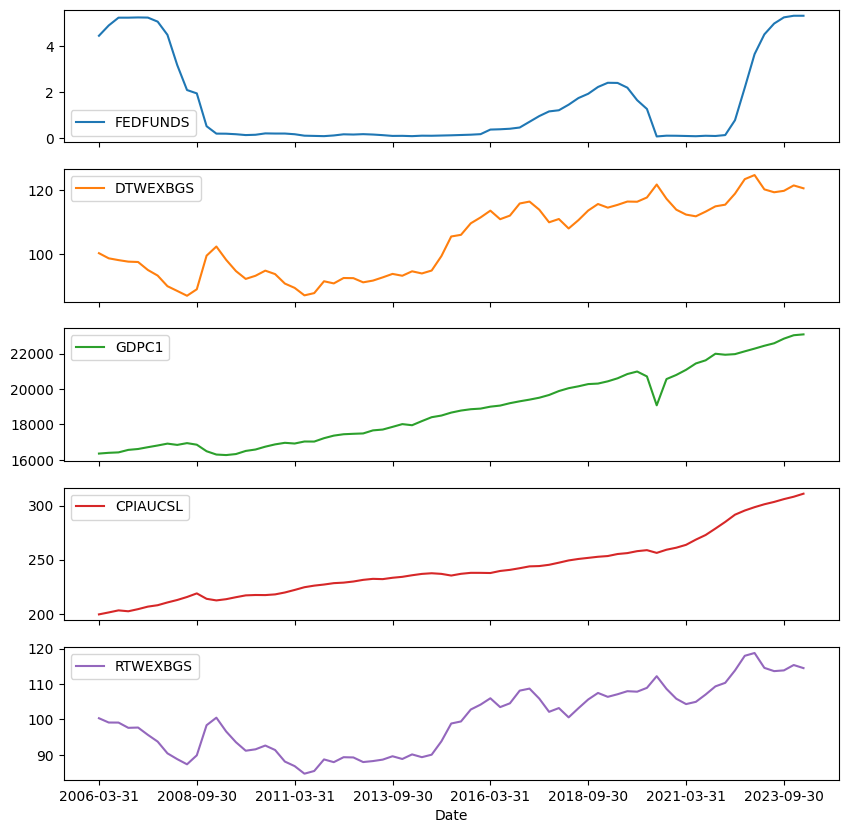

In [97]:
df.set_index('Date').drop(columns='Unnamed: 0').plot(subplots=True, figsize=(10, 10))

In [98]:
cols = ['FEDFUNDS', 'DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

for col in cols:
    x = df[col].dropna()
    reg = 'c' if col == 'FEDFUNDS' else 'ct'

    adf = adfuller(x, regression=reg, autolag='AIC')
    kp = kpss(x, regression=reg, nlags='auto')

    print(f'{col}: ADF p={adf[1]:.4f}, KPSS p={kp[1]:.4f}')

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1165661747.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(x, regression=reg, nlags='auto')
/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1165661747.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(x, regression=reg, nlags='auto')
/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1165661747.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(x, regression=reg, nlags='auto')


FEDFUNDS: ADF p=0.1040, KPSS p=0.1000
DTWEXBGS: ADF p=0.0820, KPSS p=0.0371
GDPC1: ADF p=0.2802, KPSS p=0.0100
CPIAUCSL: ADF p=0.9950, KPSS p=0.0100
RTWEXBGS: ADF p=0.1080, KPSS p=0.0137


In [99]:
cols_log = ['DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

data = pd.DataFrame()
data['FEDFUNDS'] = df['FEDFUNDS'].diff()

for col in cols_log:
    data[col] = np.log(df[col]).diff()

data = data.dropna()

for col in data:
    adf = adfuller(data[col], regression='c', autolag='AIC')
    kp = kpss(data[col], regression='c', nlags='auto')
    print(f'{col}: ADF p={adf[1]:.4f}, KPSS p={kp[1]:.4f}')

/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1005432308.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(data[col], regression='c', nlags='auto')
/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1005432308.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(data[col], regression='c', nlags='auto')
/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_2074/1005432308.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(data[col], regression='c', nlags='auto')


FEDFUNDS: ADF p=0.0034, KPSS p=0.0886
DTWEXBGS: ADF p=0.0000, KPSS p=0.1000
GDPC1: ADF p=0.0000, KPSS p=0.1000
CPIAUCSL: ADF p=0.0000, KPSS p=0.0848
RTWEXBGS: ADF p=0.0000, KPSS p=0.1000


# Сезонность

По сути ее нет, но нудны лаги таргета

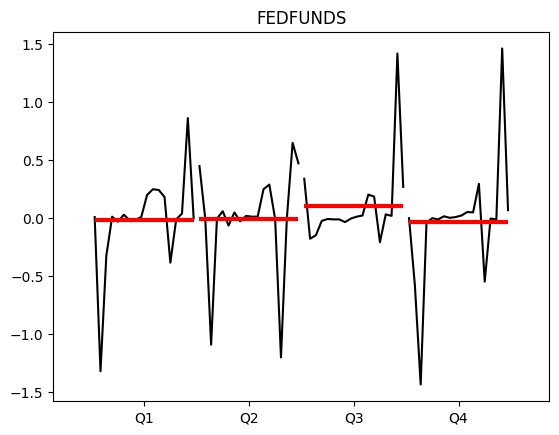

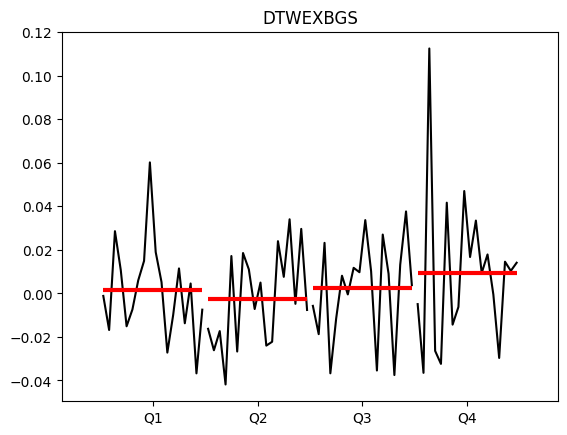

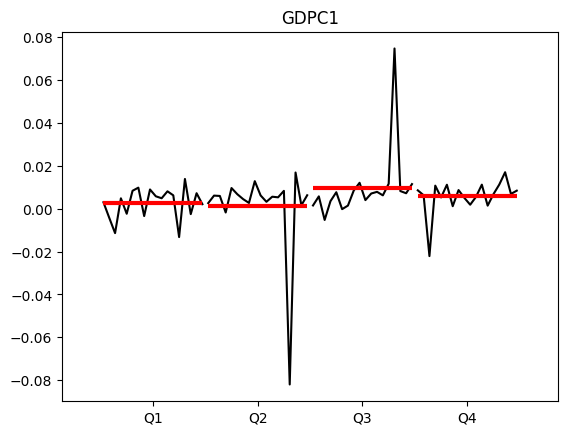

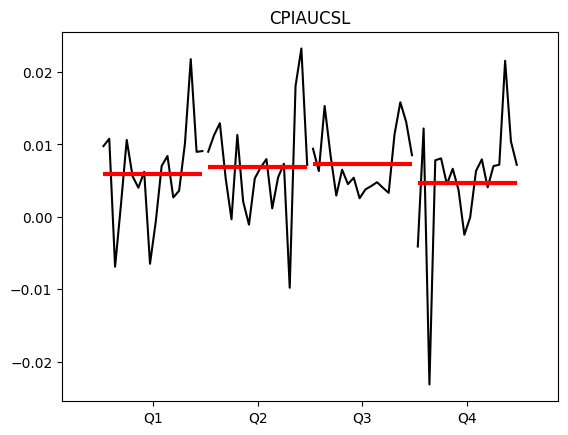

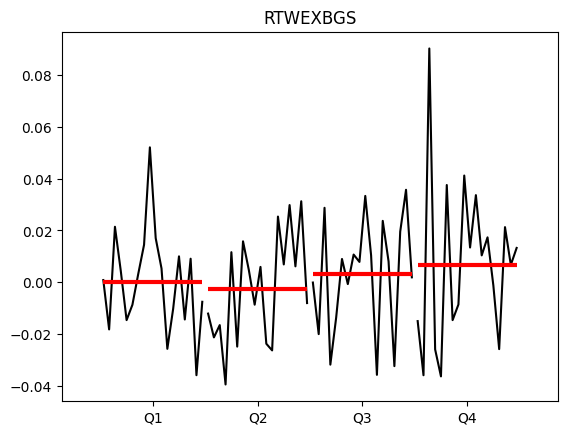

In [100]:
for col in data.columns:
    x = data[col].dropna()
    x.index = pd.PeriodIndex(df.loc[x.index, 'Date'], freq='Q')
    
    seasonal_plot(x.groupby(x.index.quarter), ['Q1','Q2','Q3','Q4'])
    plt.title(col)
    plt.show()

In [101]:
for col in data.columns:
    x = data[[col]].copy()
    x['Q'] = pd.to_datetime(df.loc[x.index, 'Date']).dt.quarter
    m = smf.ols(f'{col} ~ C(Q)', data=x).fit()
    print(col, m.f_pvalue)

FEDFUNDS 0.7840909089171697
DTWEXBGS 0.5961181384968841
GDPC1 0.31249145250304655
CPIAUCSL 0.70728744157434
RTWEXBGS 0.6999197287916465


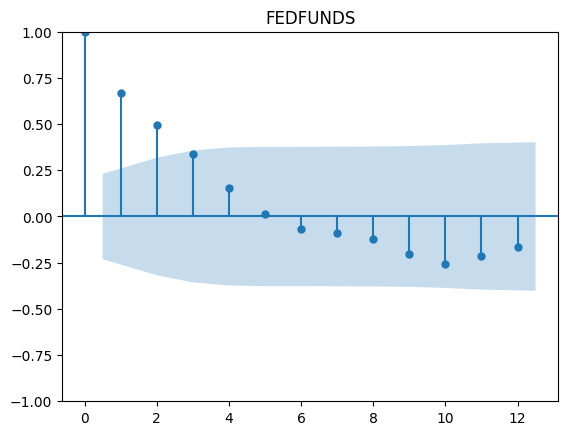

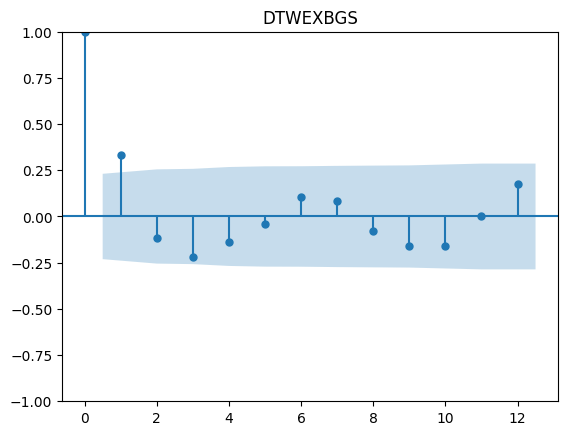

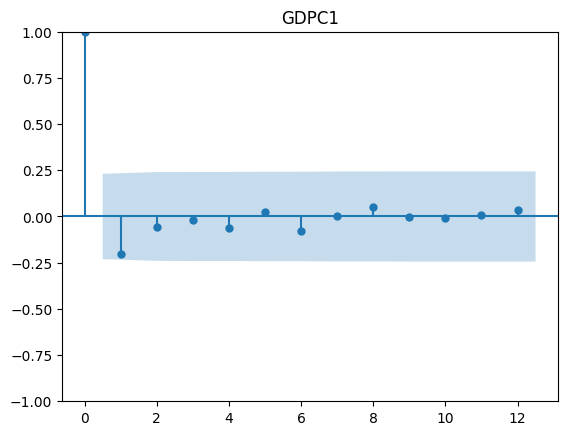

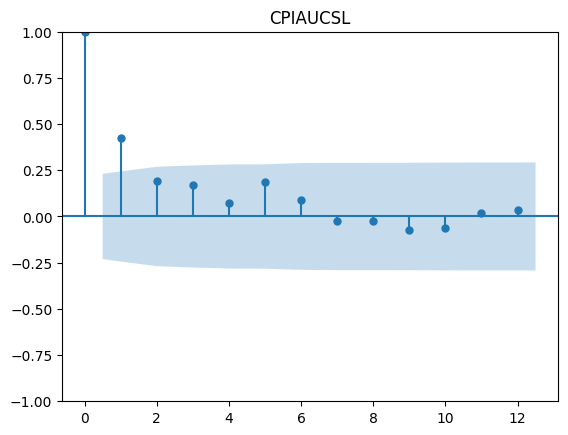

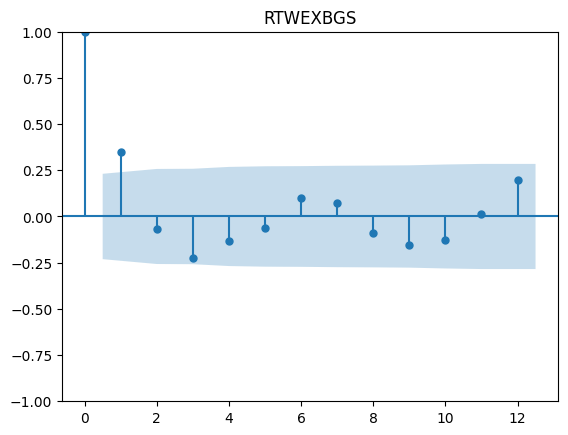

In [102]:
for col in data.columns:
    plot_acf(data[col].dropna(), lags=12, title=col)
    plt.show()

# Рапсределение

В целом после преобразований относительно близко к нормальному, но есть выбросы

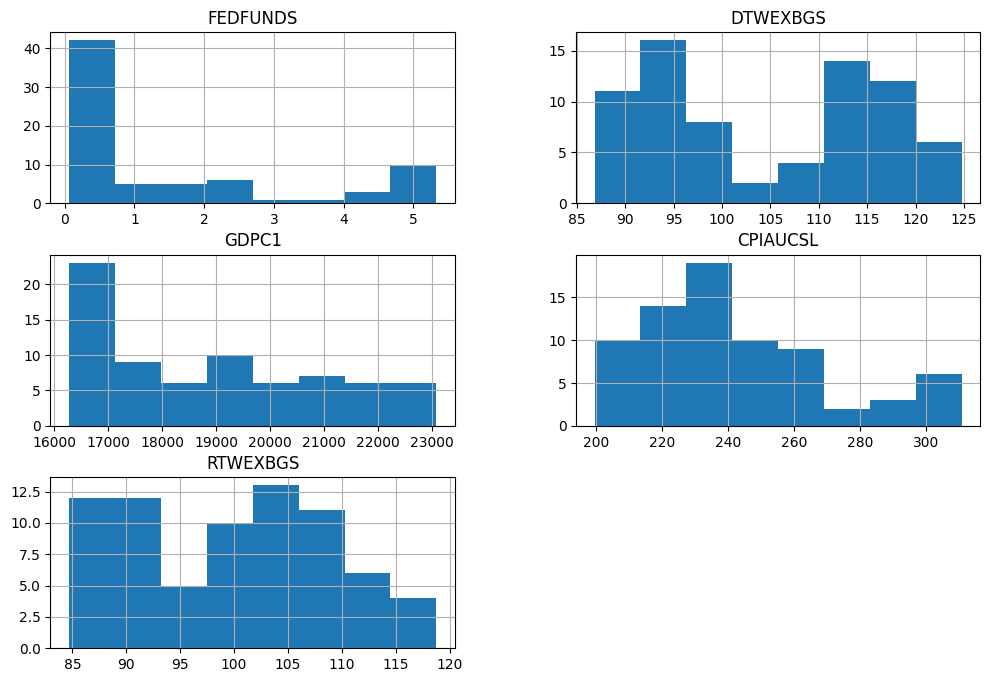

In [103]:
cols = ['FEDFUNDS', 'DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

df[cols].hist(figsize=(12, 8), bins= 'auto')
plt.show()

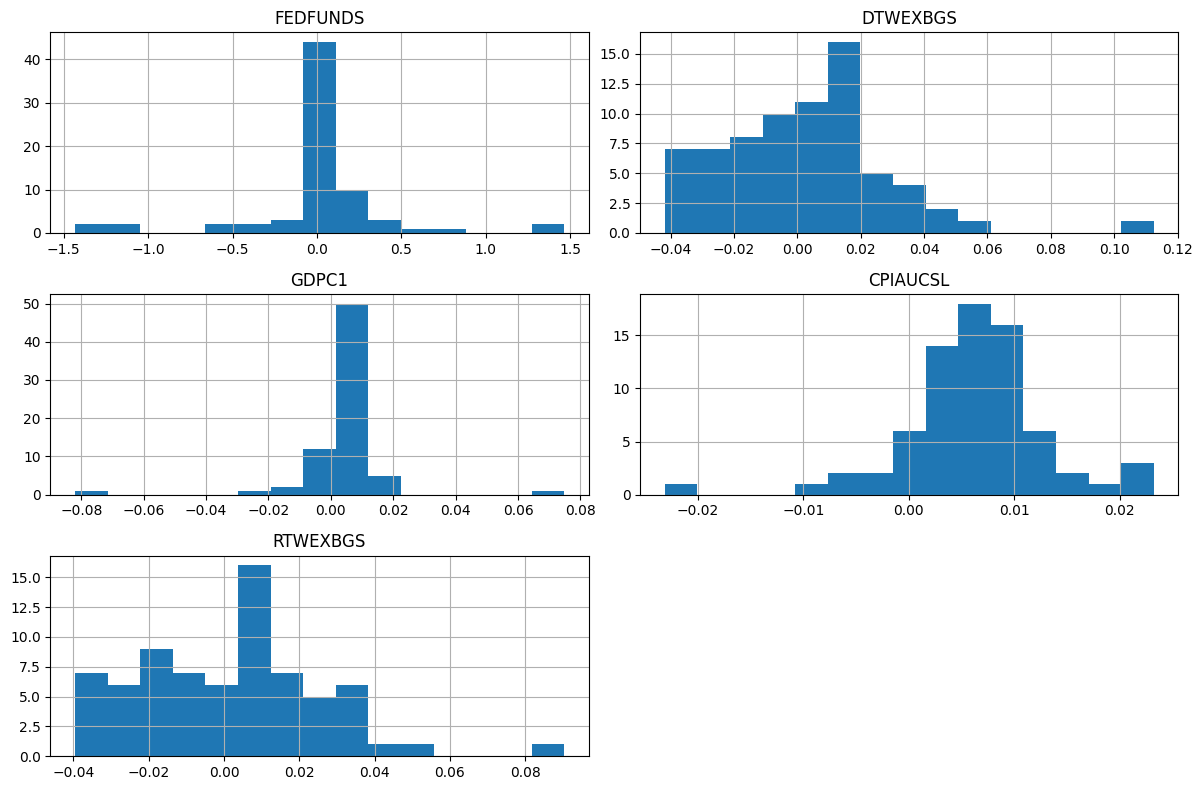

In [104]:
data.hist(figsize=(12, 8), bins=15)
plt.tight_layout()
plt.show()

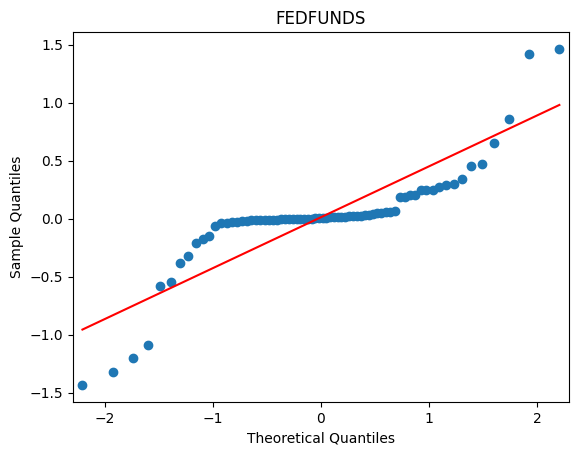

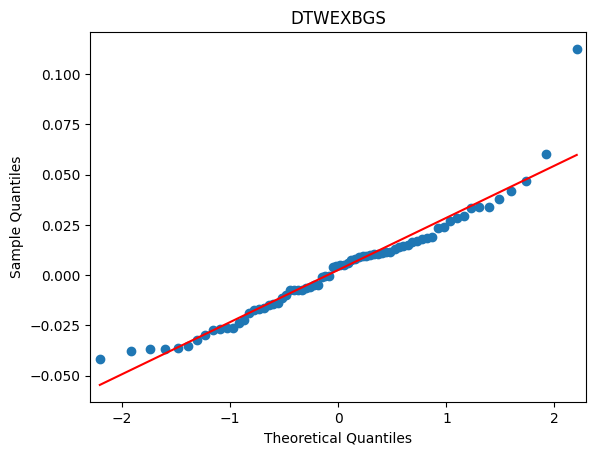

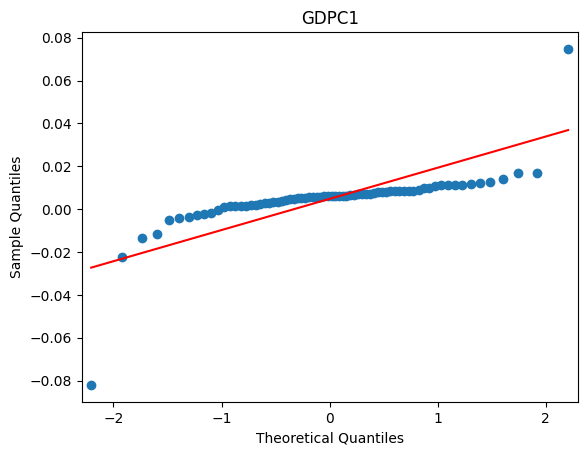

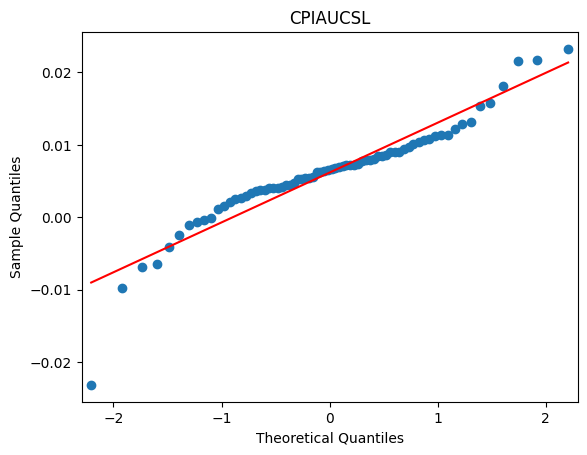

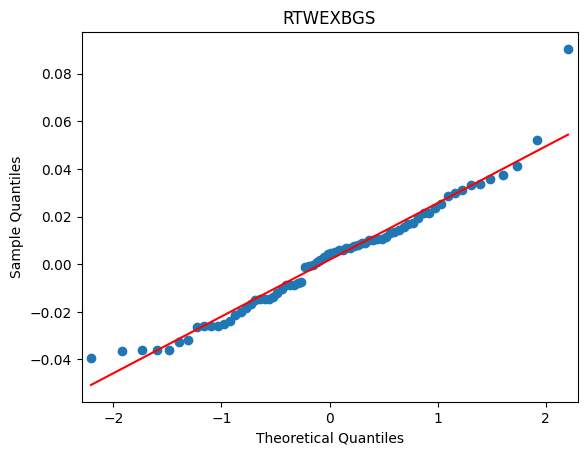

In [105]:
for col in data.columns:
    sm.qqplot(data[col].dropna(), line='s')
    plt.title(col)
    plt.show()

# Связи с таргетом

Линейная связь все время меняет знак, в целом можно зашить ее тригономом (типа фича*sin(t) например)

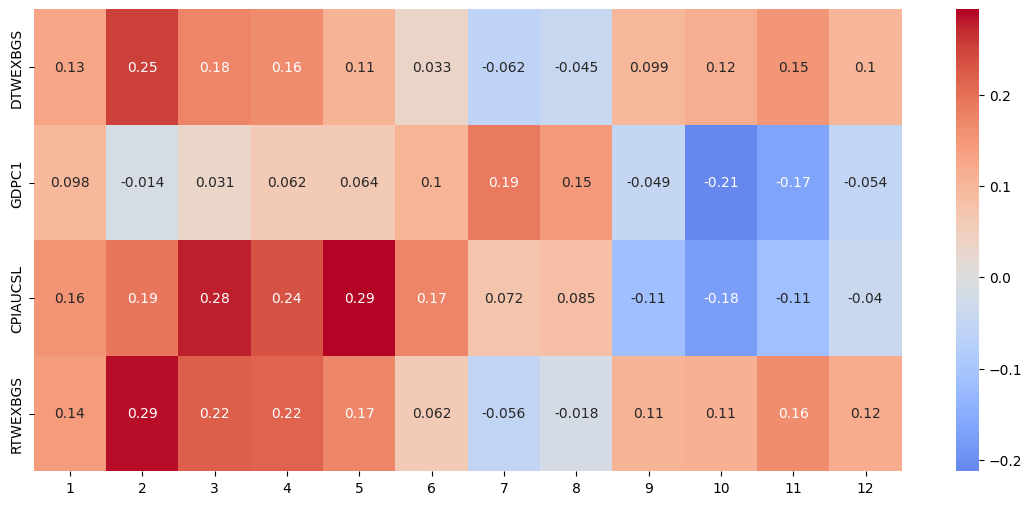

In [106]:
features = data.columns.drop('FEDFUNDS')
corr = pd.DataFrame({
    lag: [data[f].shift(lag).corr(data['FEDFUNDS']) for f in features]
    for lag in range(1, 13)
}, index=features)
plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

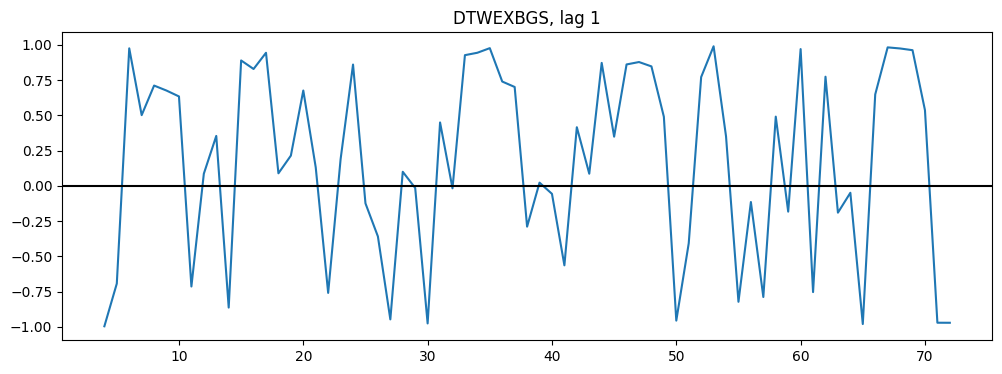

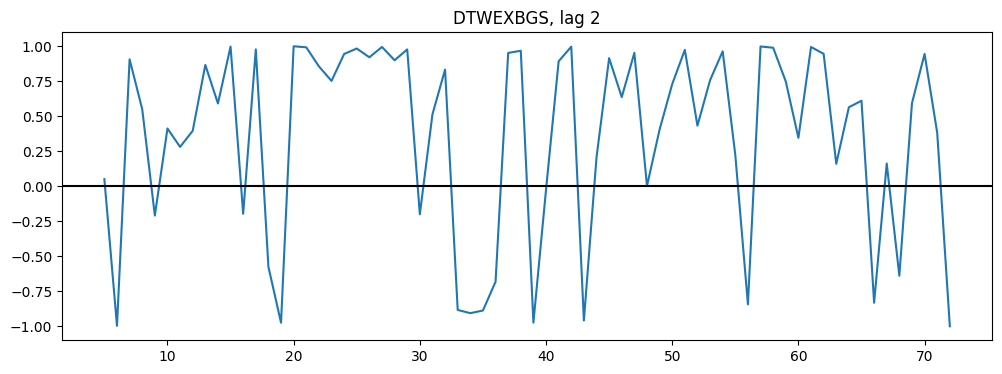

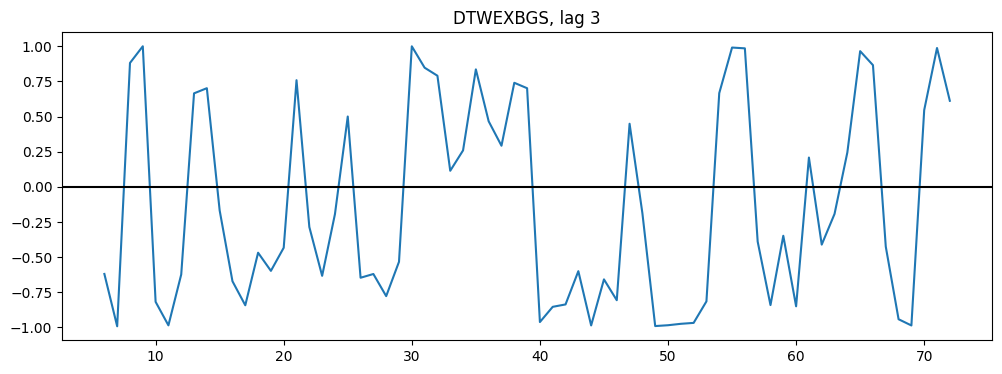

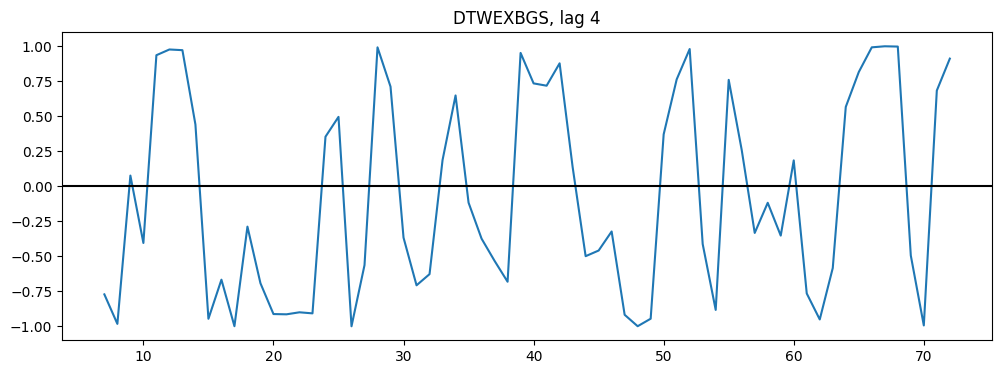

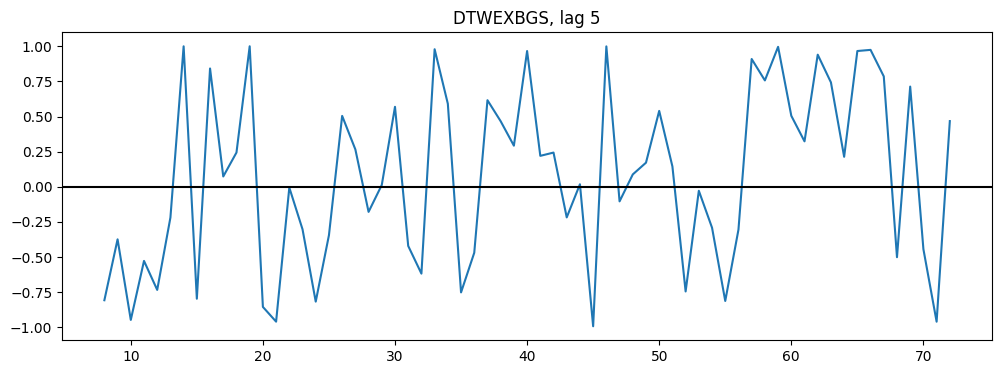

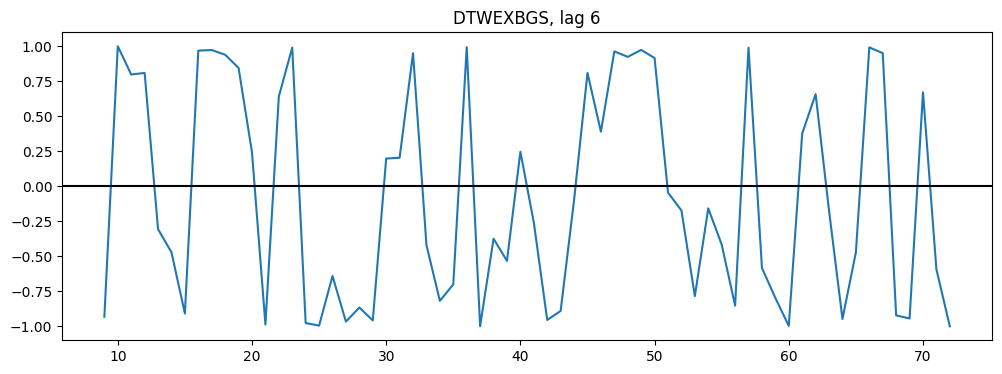

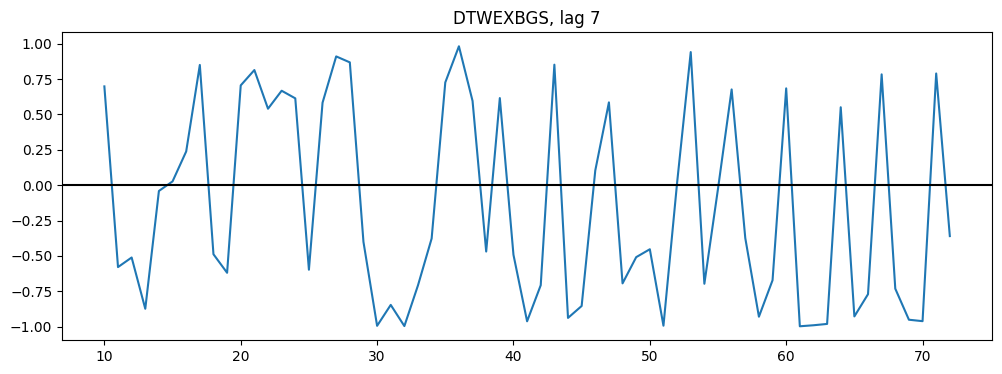

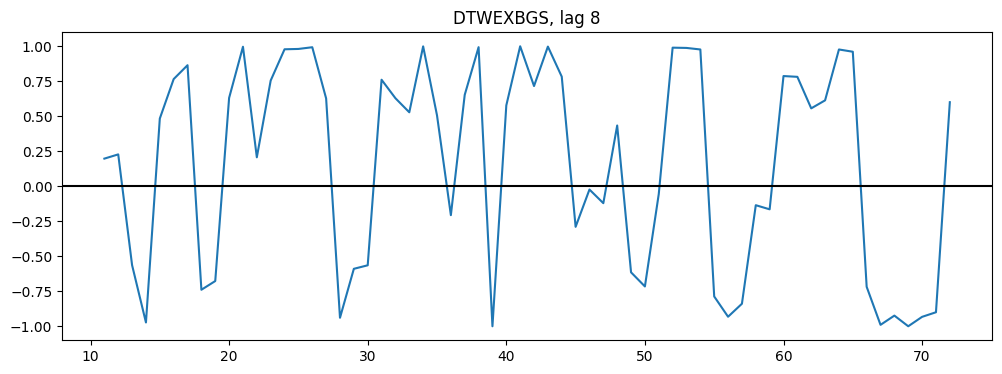

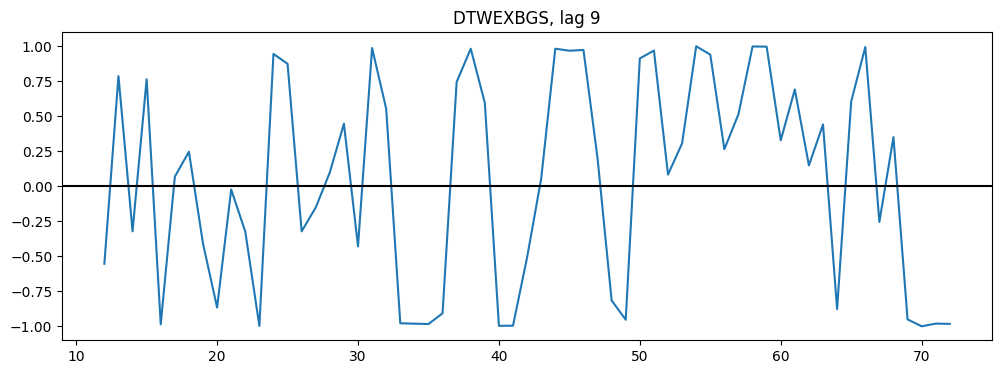

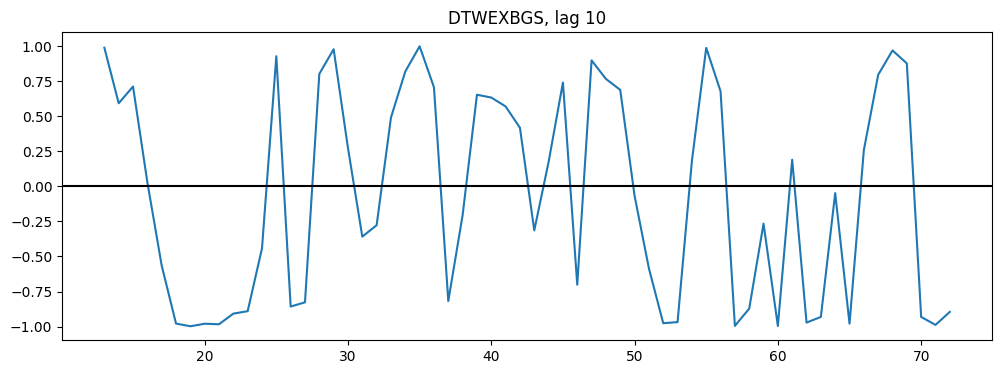

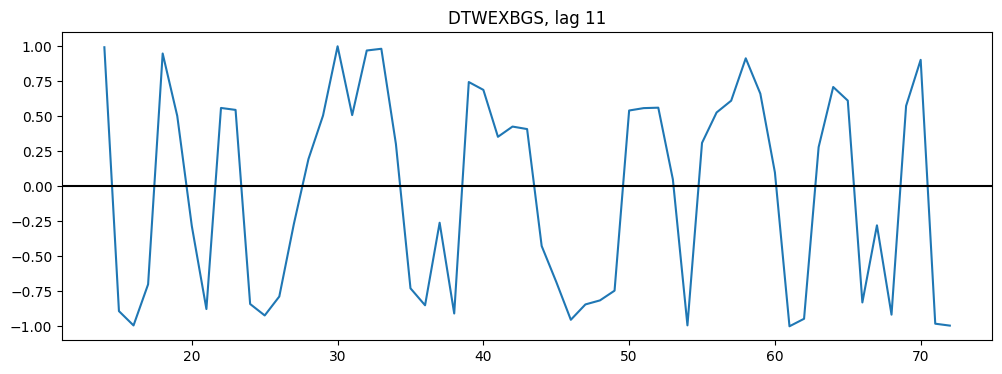

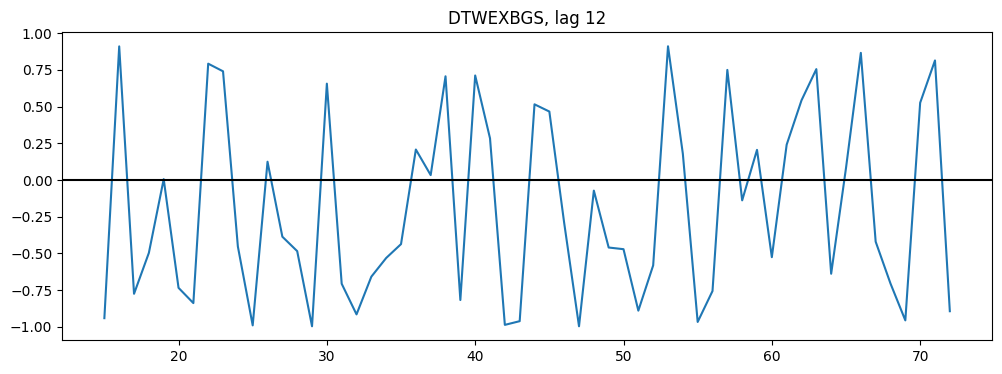

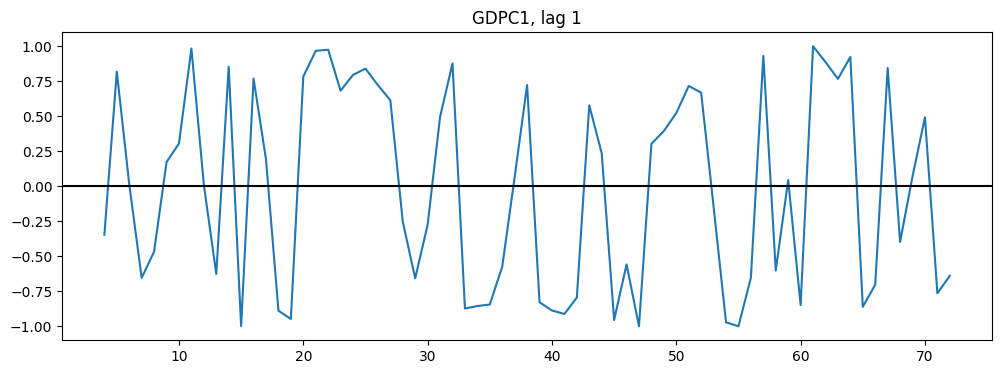

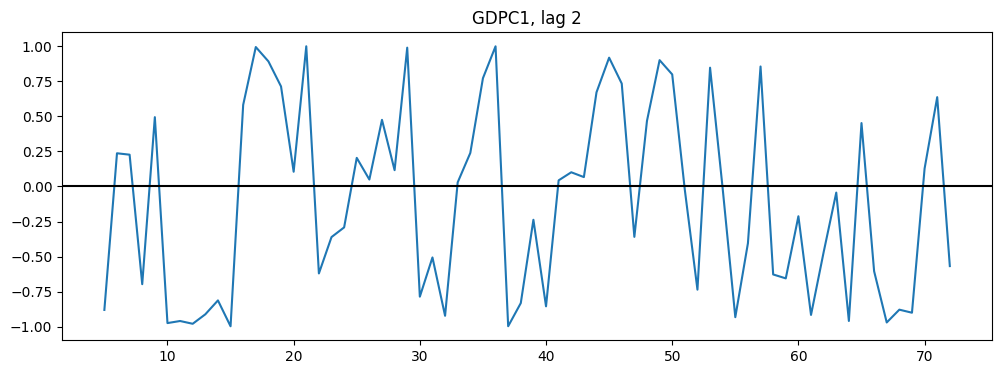

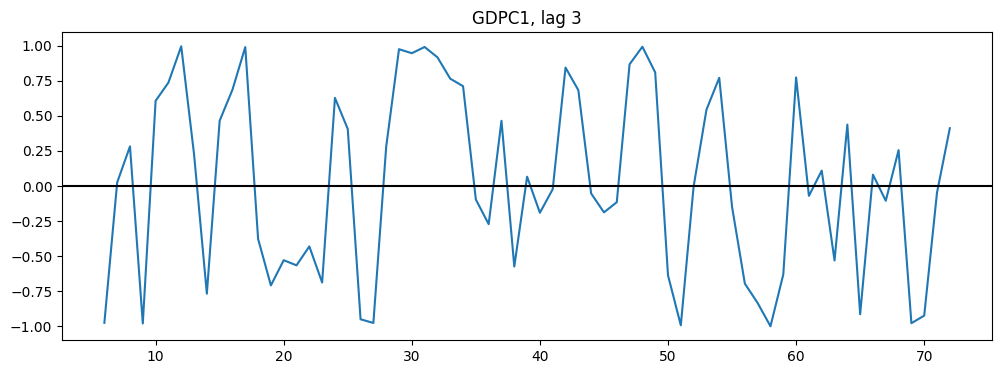

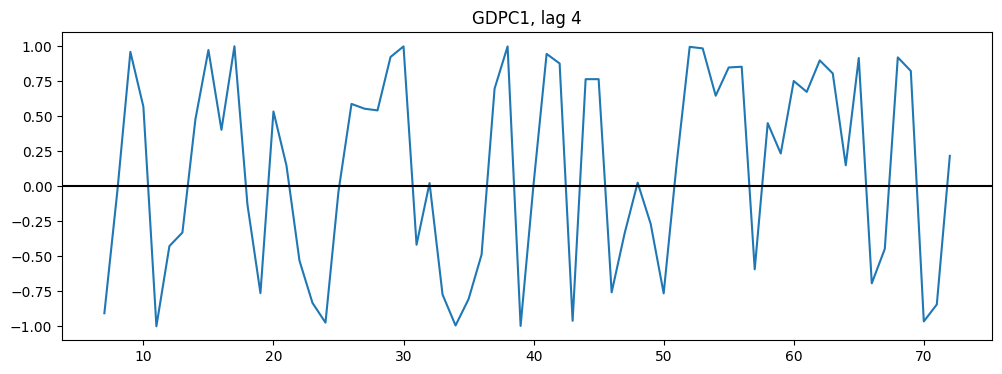

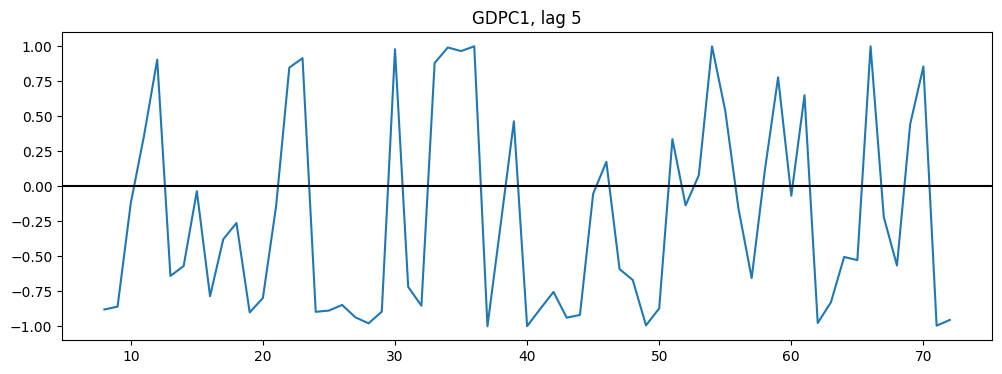

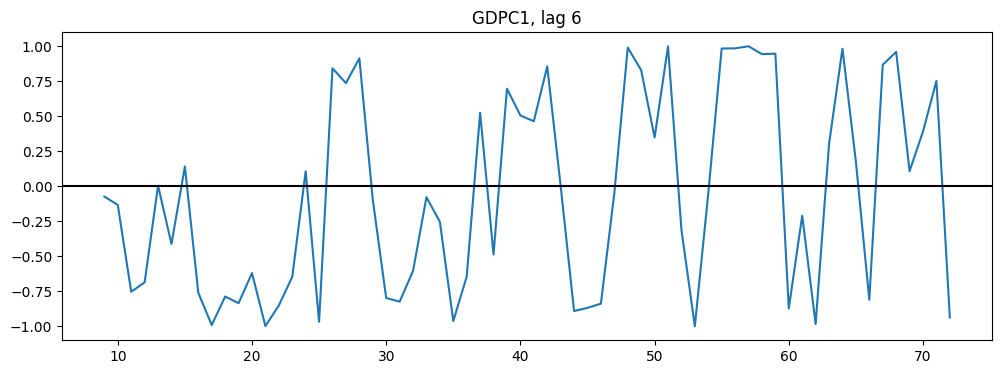

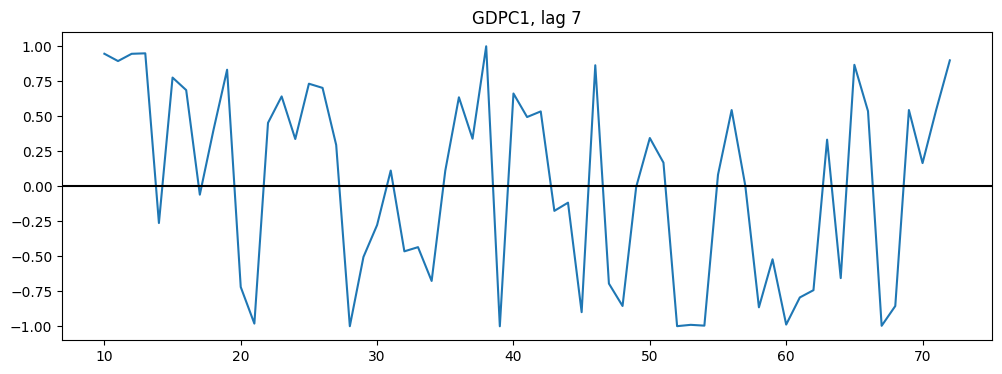

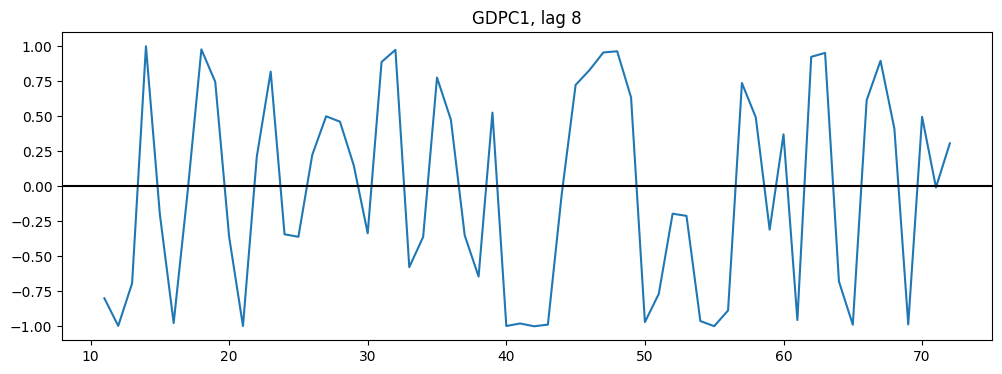

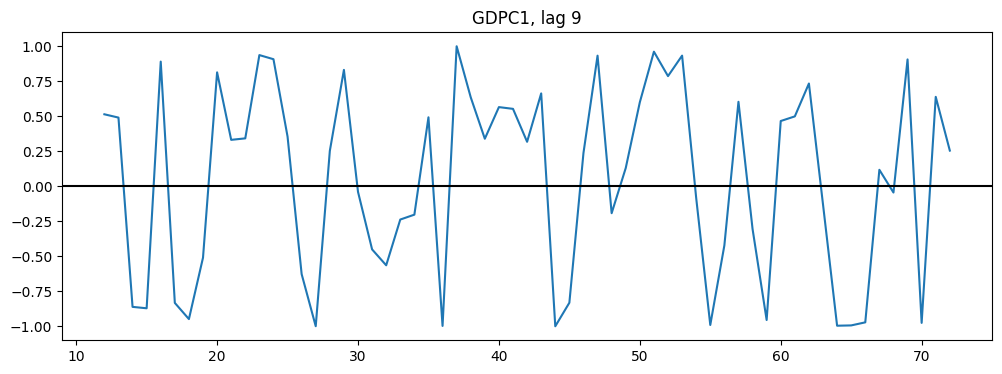

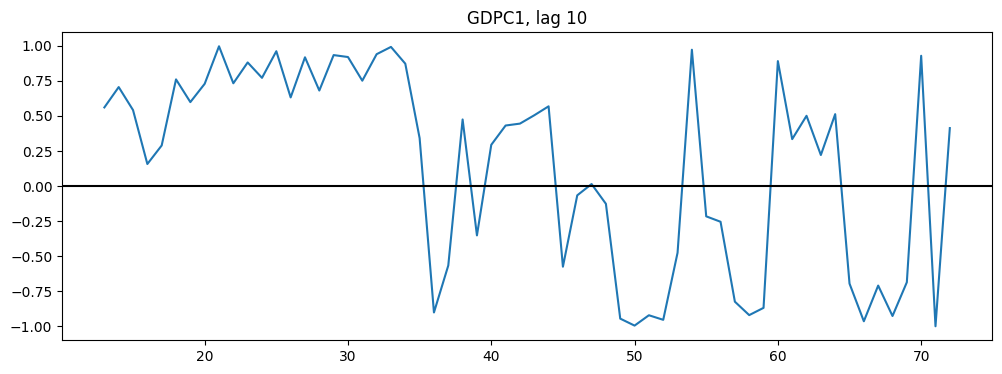

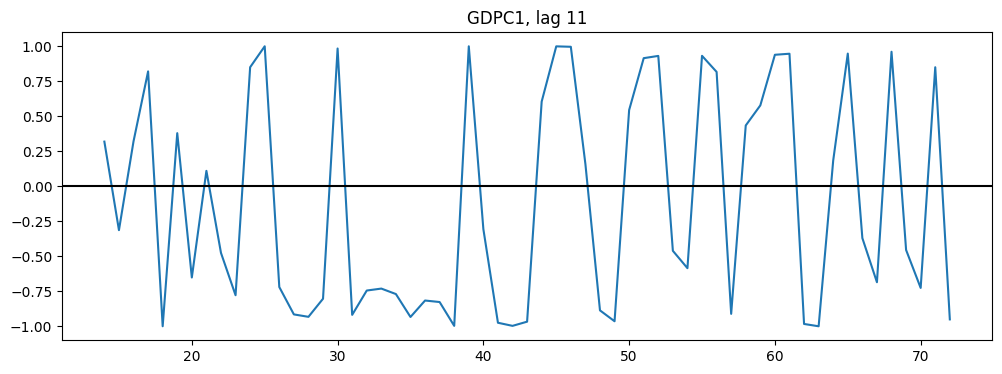

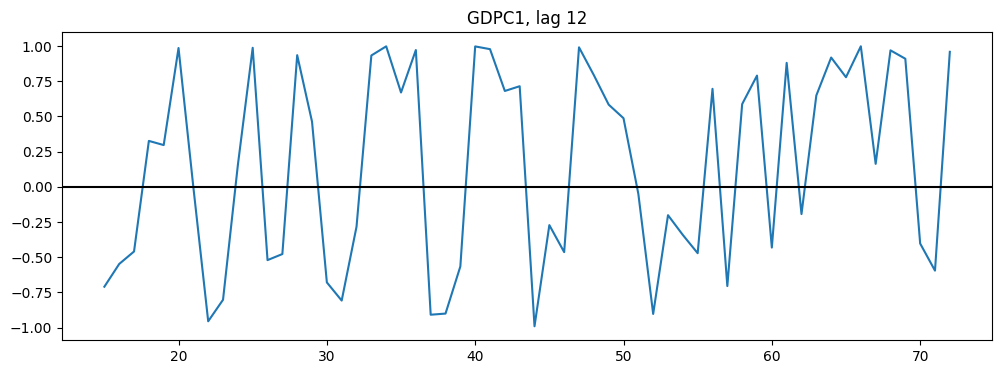

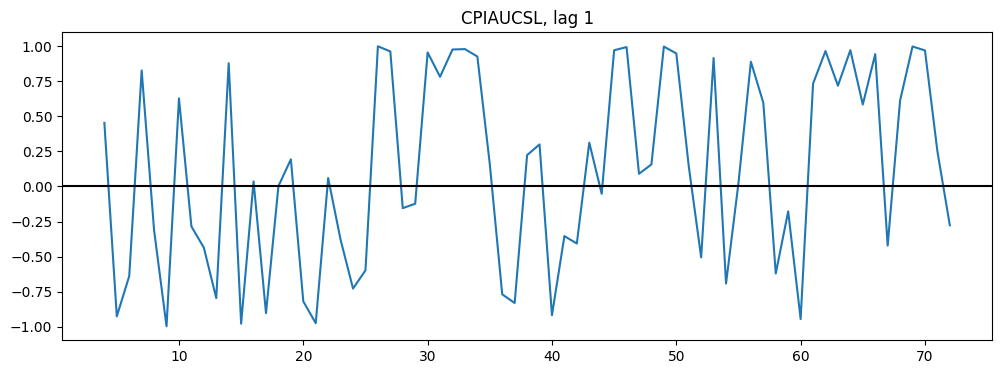

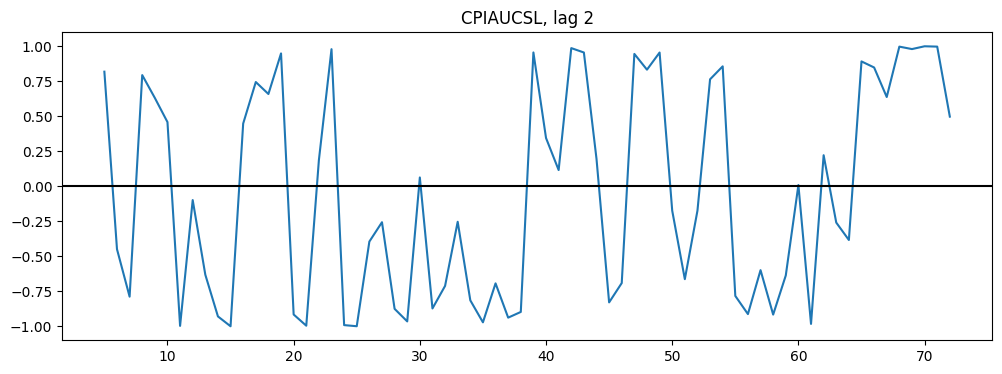

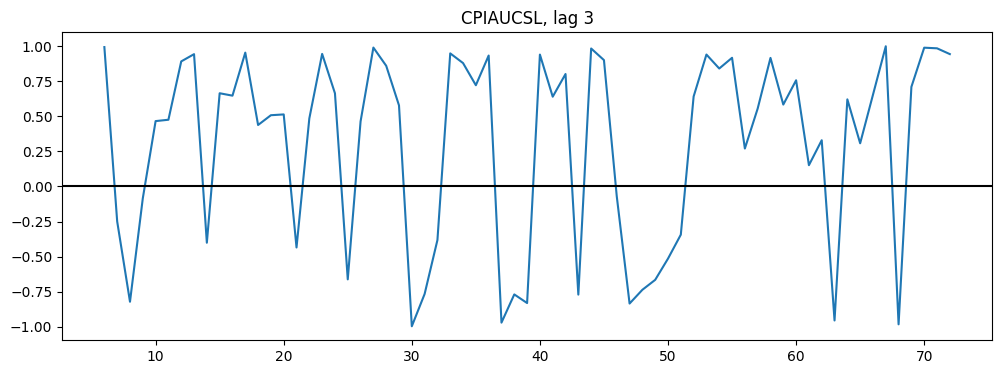

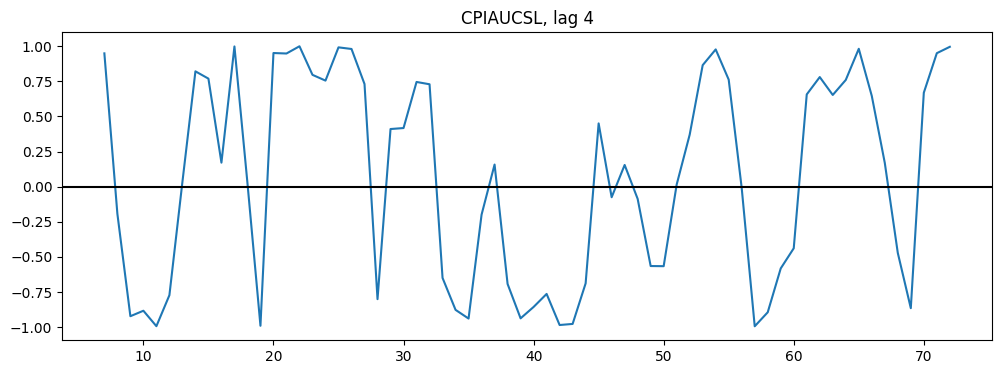

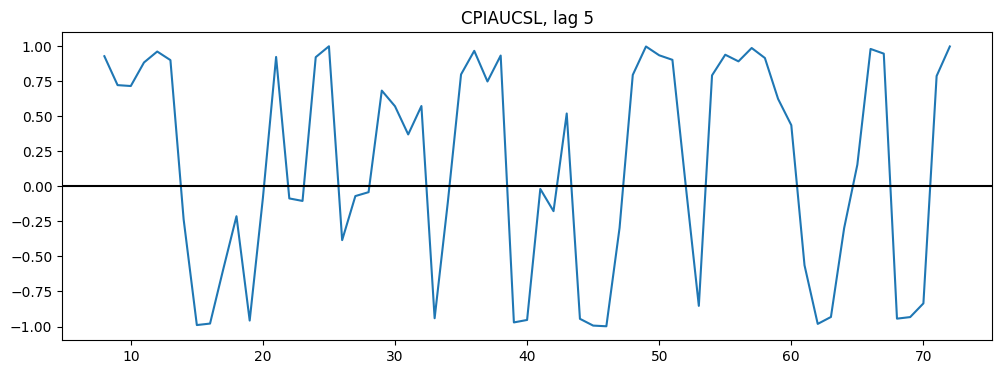

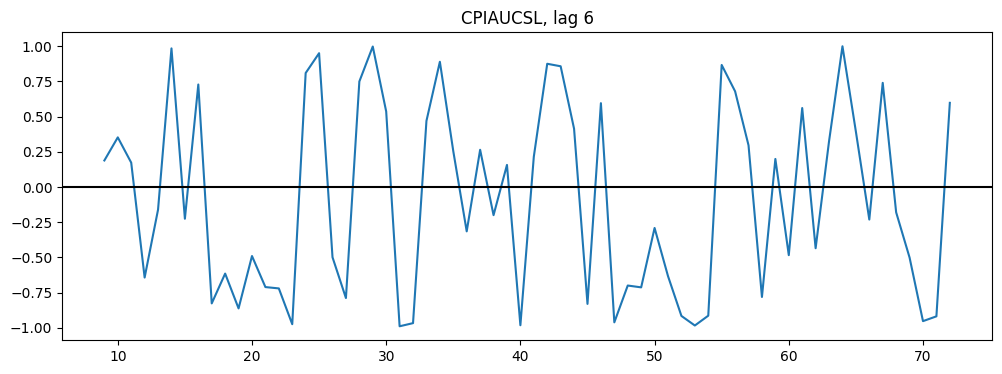

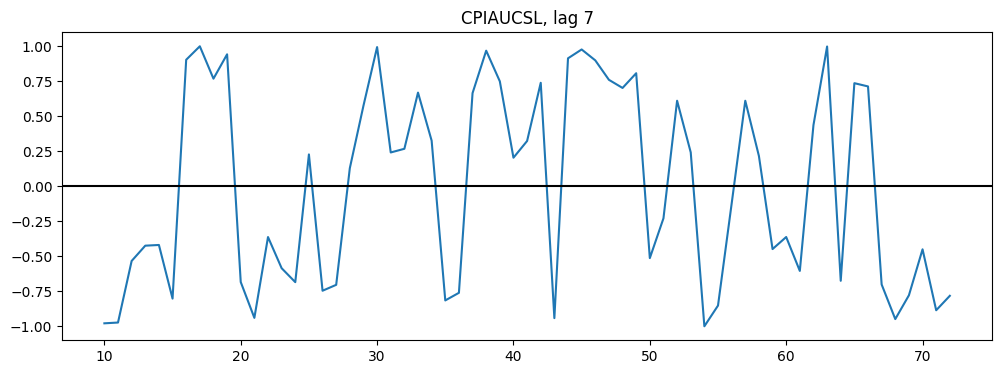

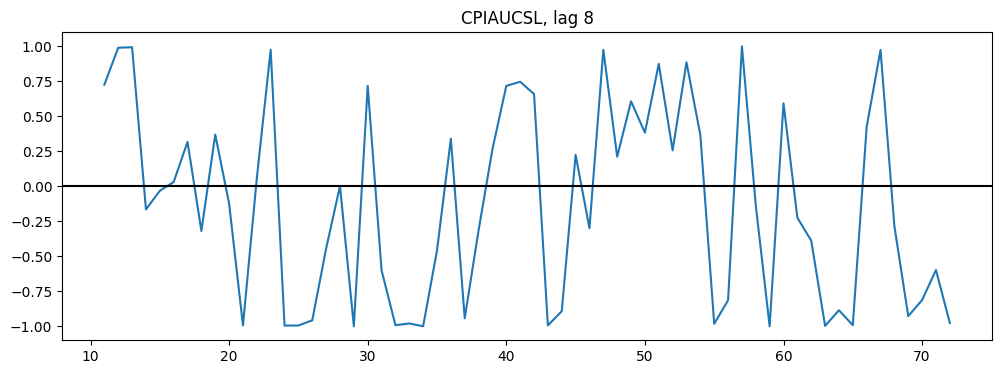

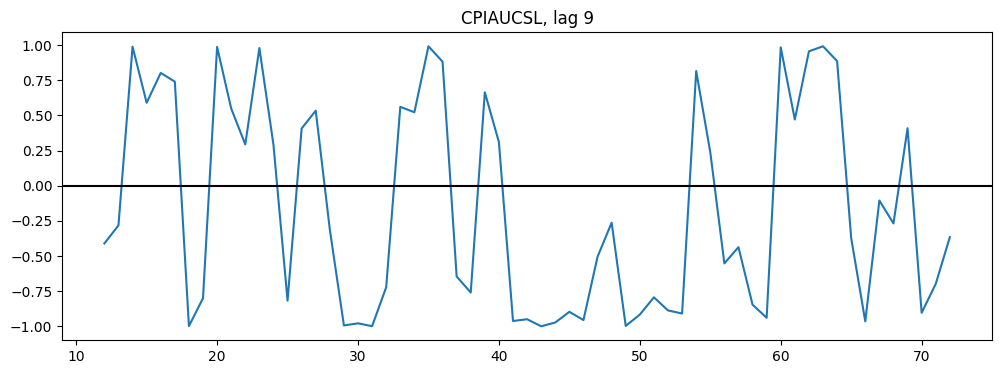

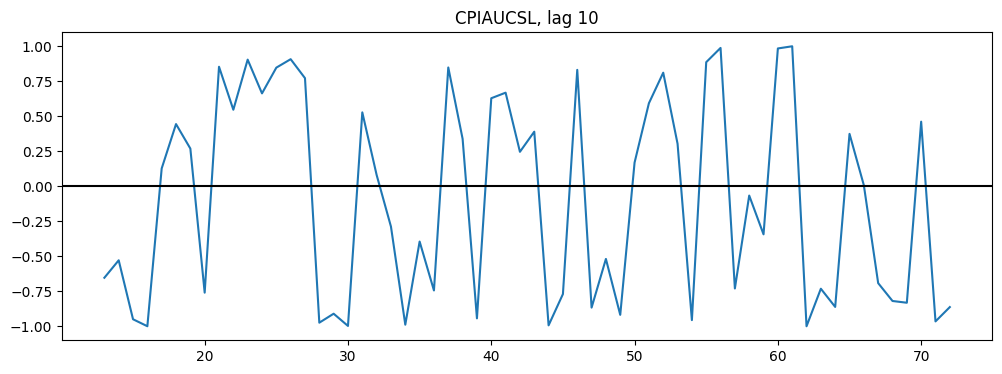

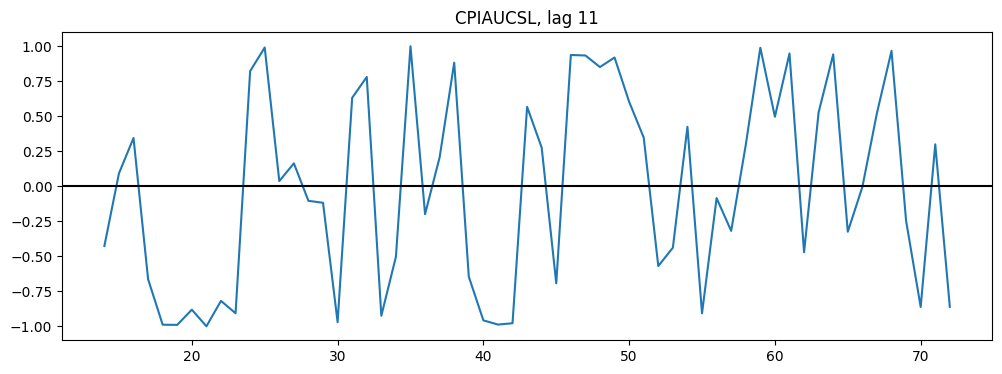

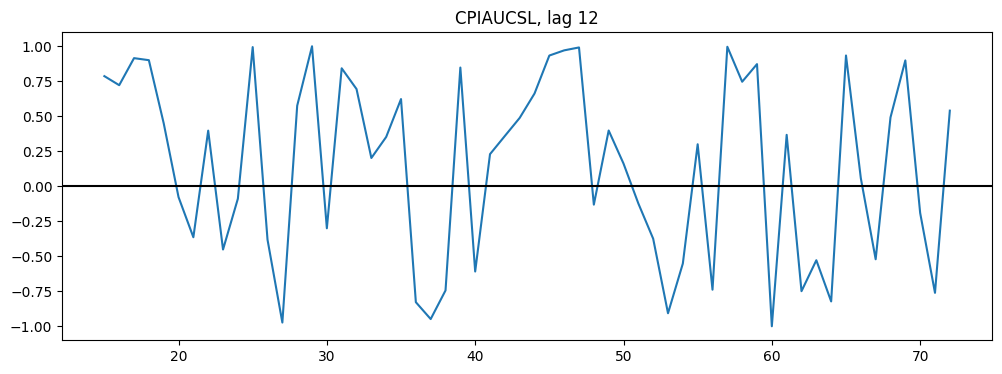

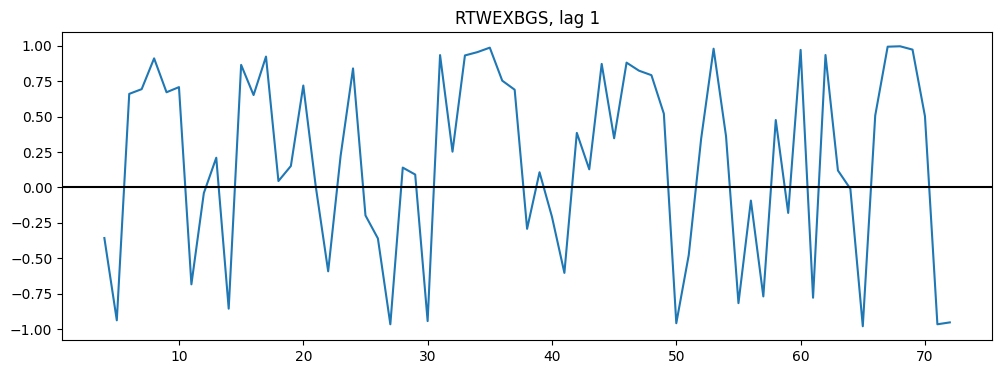

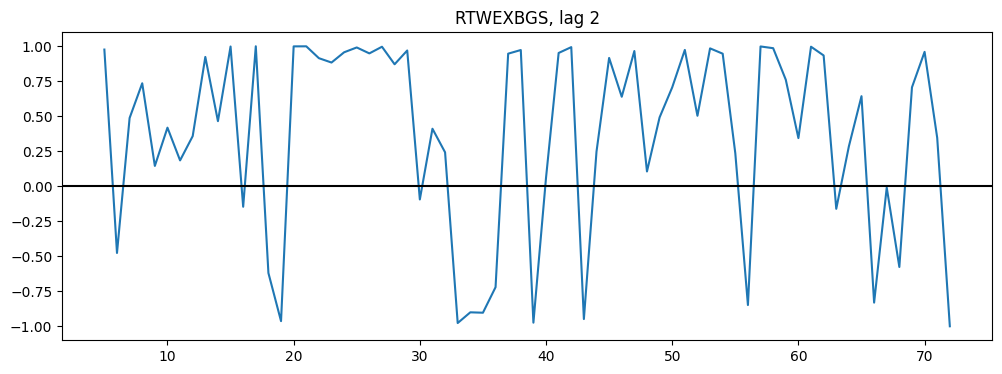

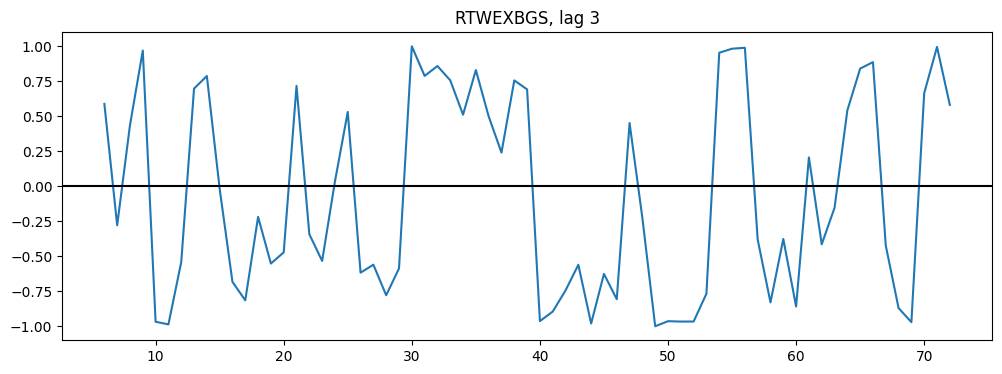

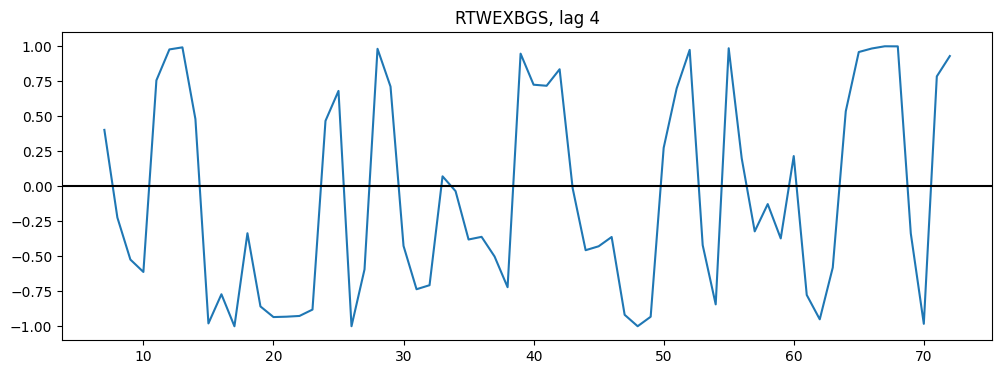

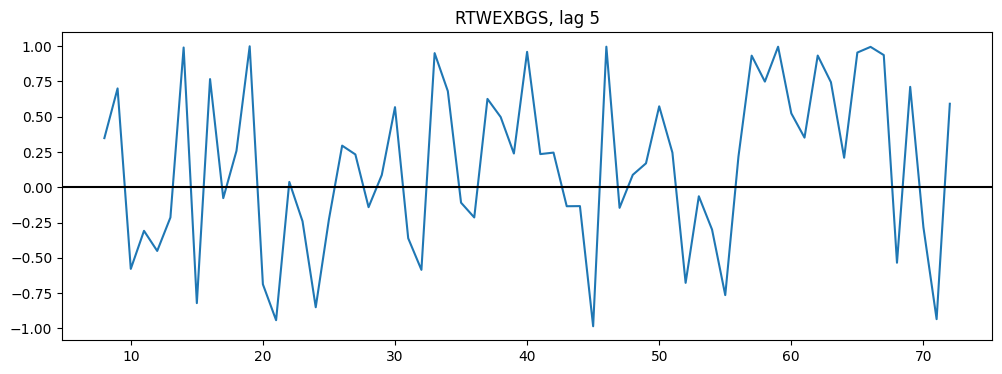

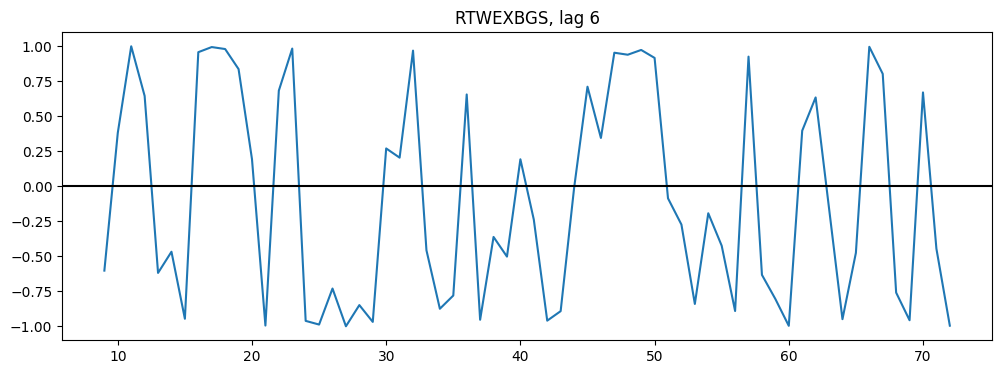

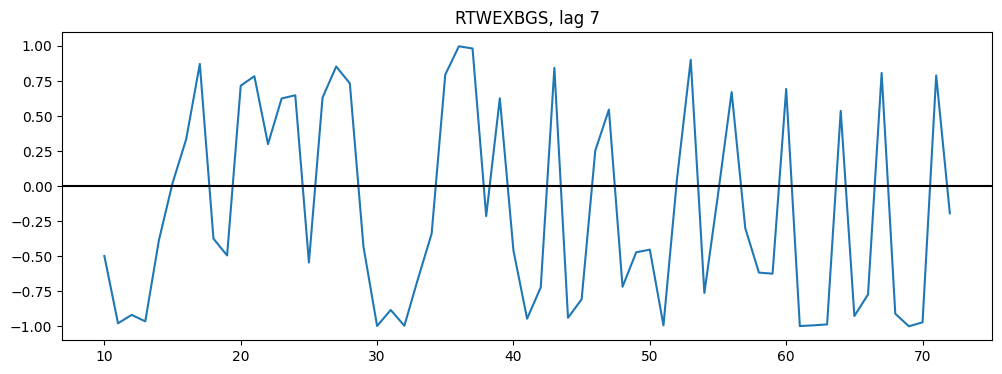

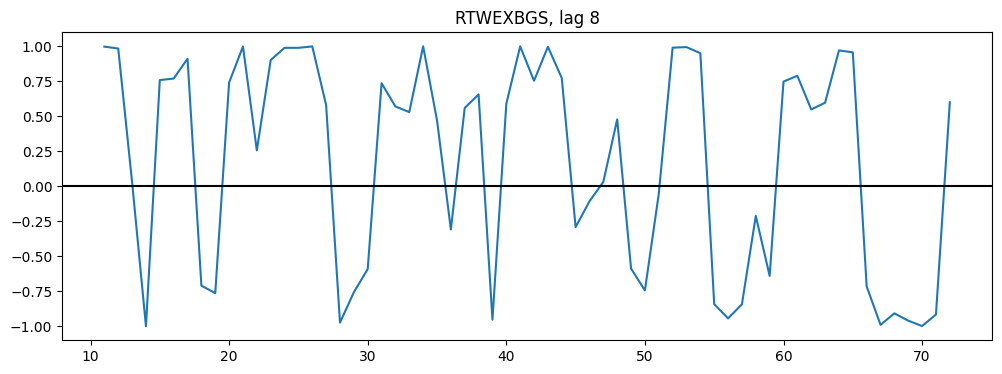

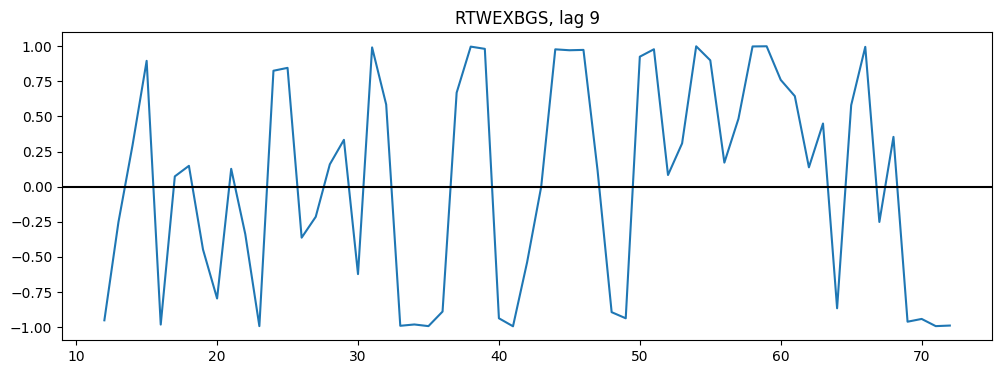

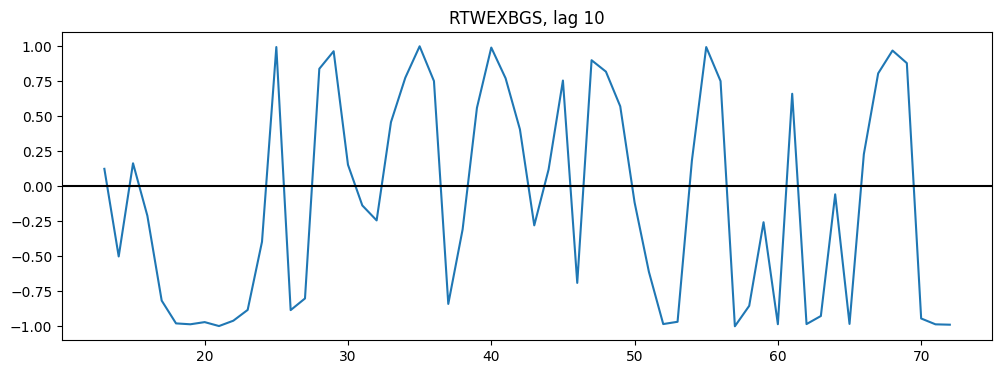

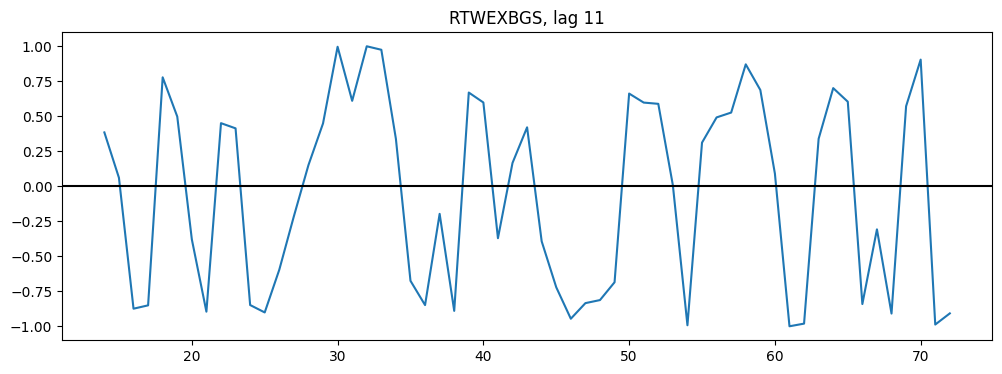

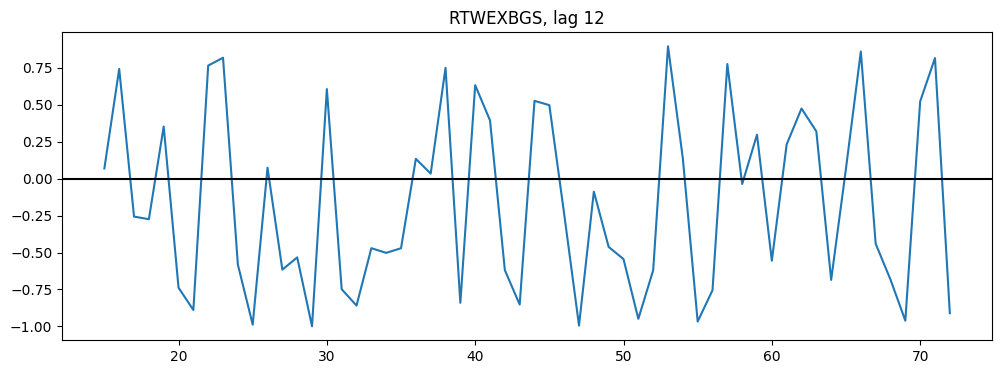

In [107]:
for f in data.columns.drop('FEDFUNDS'):
    for lag in range(1, 13):
        r = data['FEDFUNDS'].rolling(3).corr(data[f].shift(lag))
        r.plot(figsize=(12, 4), title=f'{f}, lag {lag}')
        plt.axhline(0, color='black')
        plt.show()

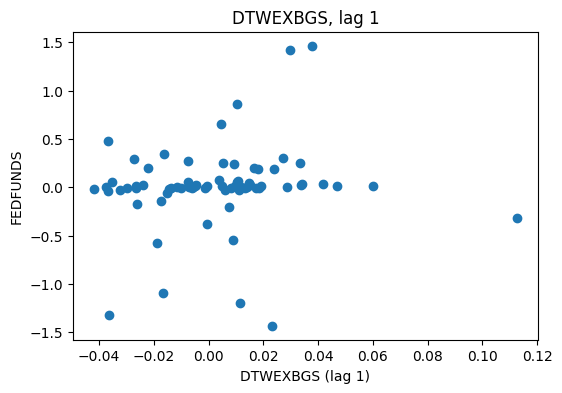

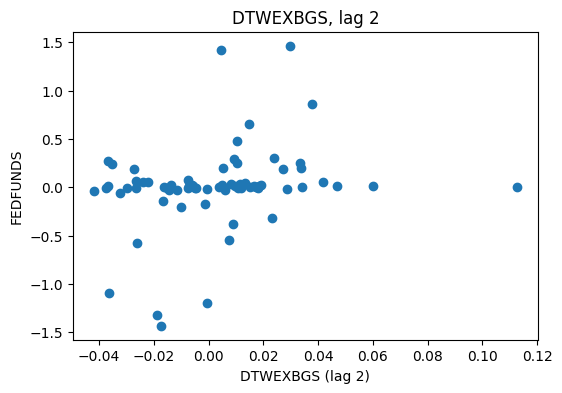

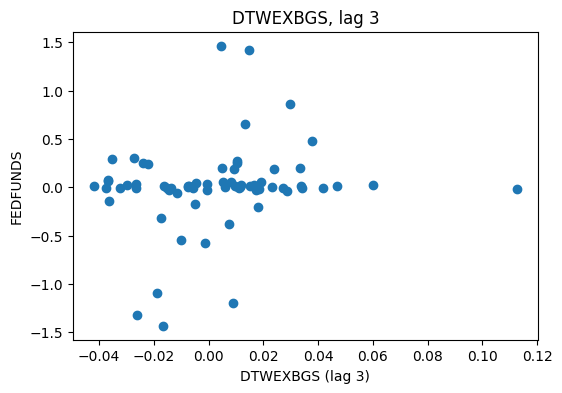

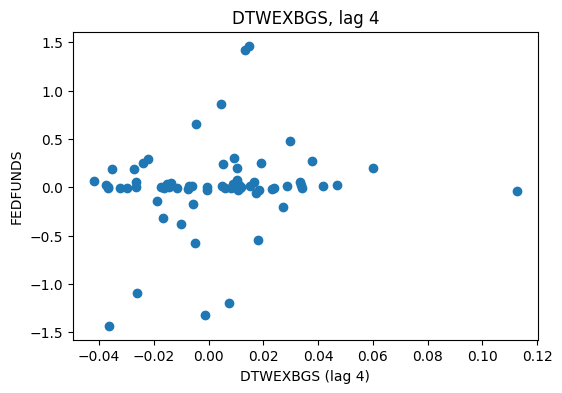

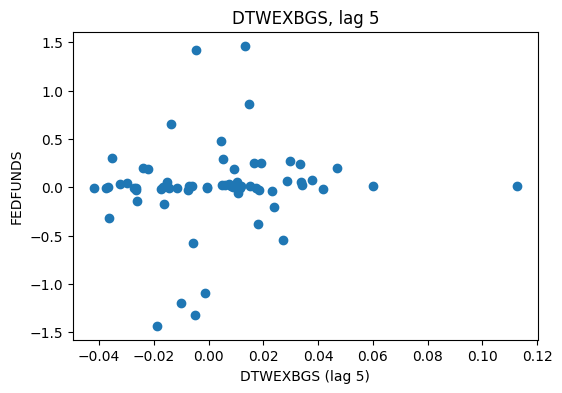

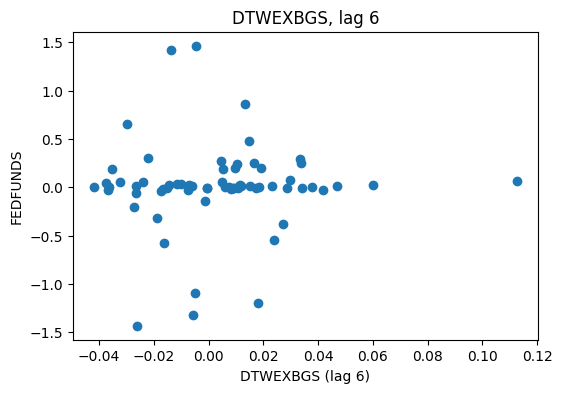

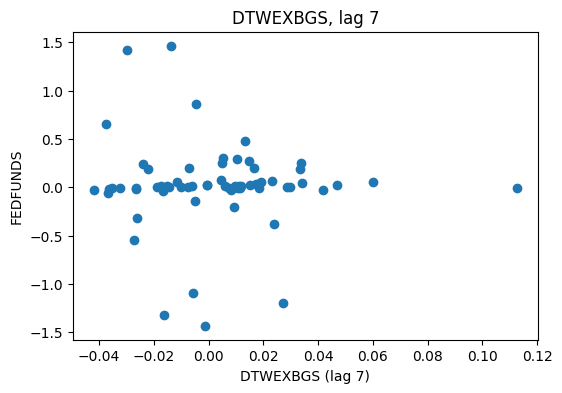

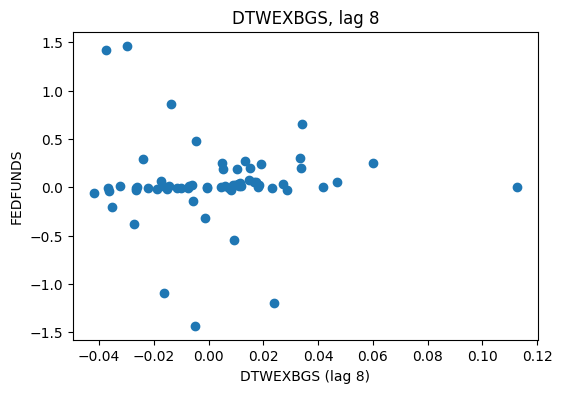

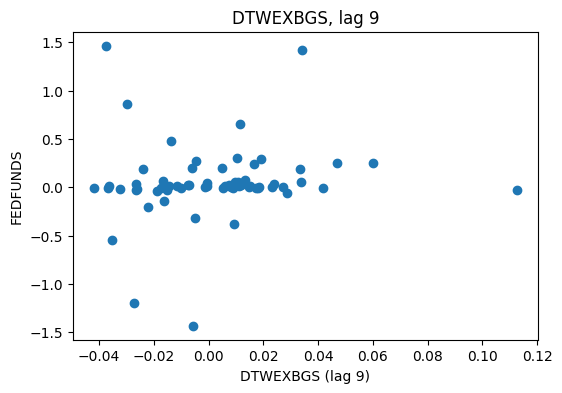

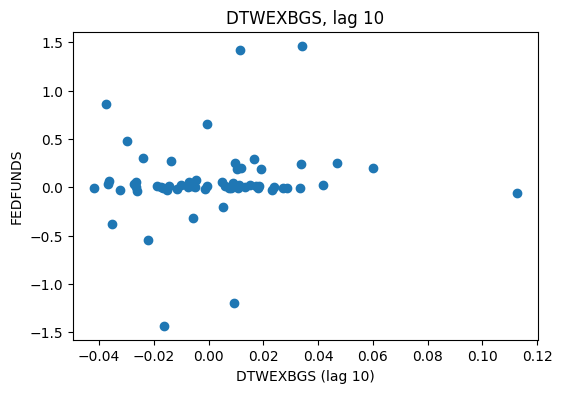

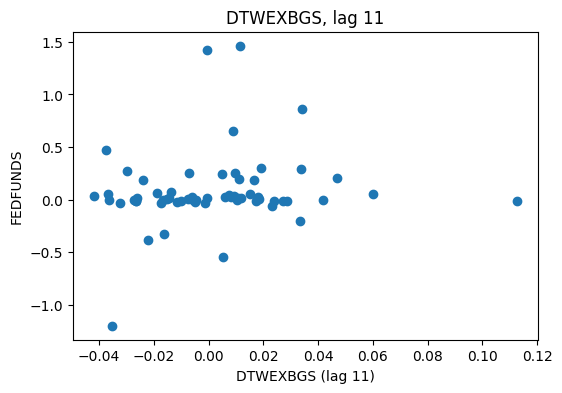

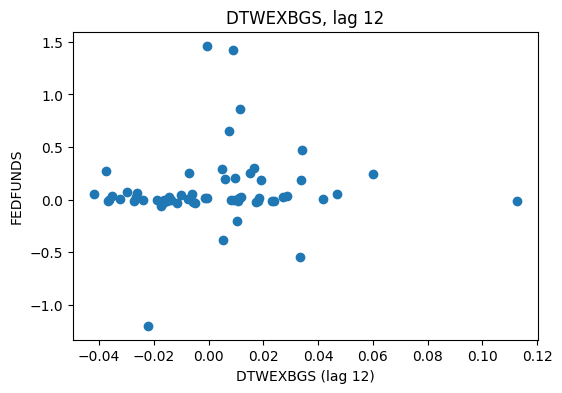

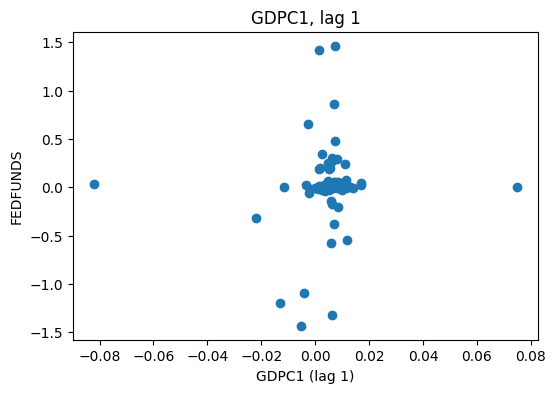

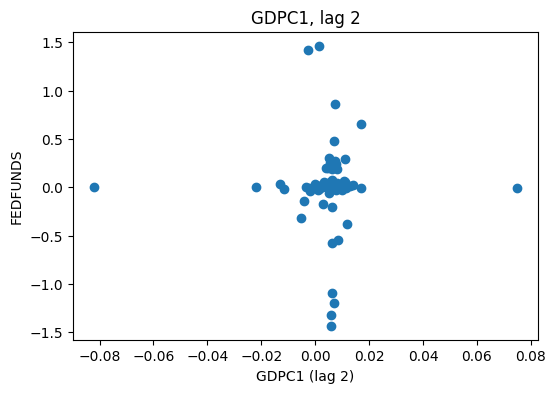

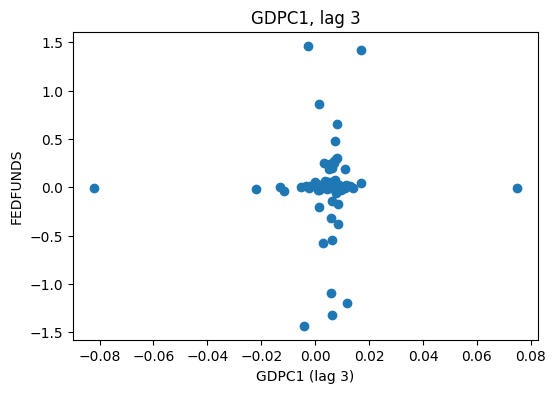

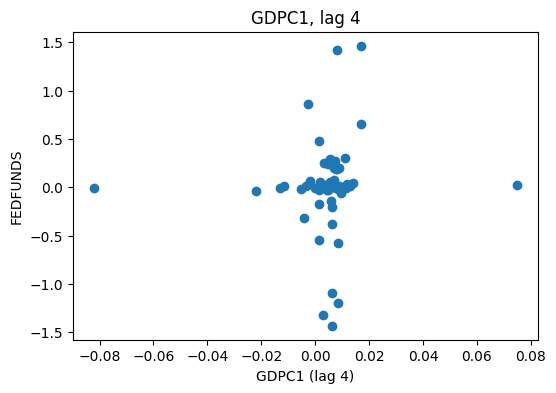

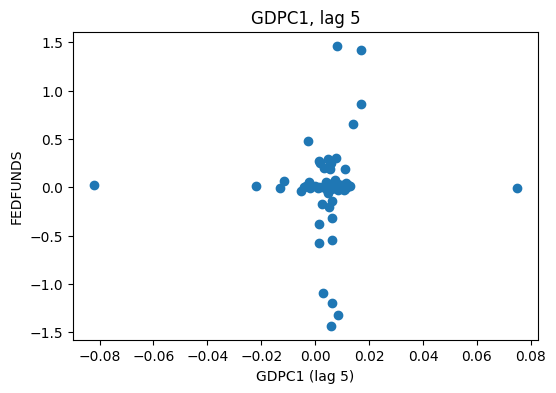

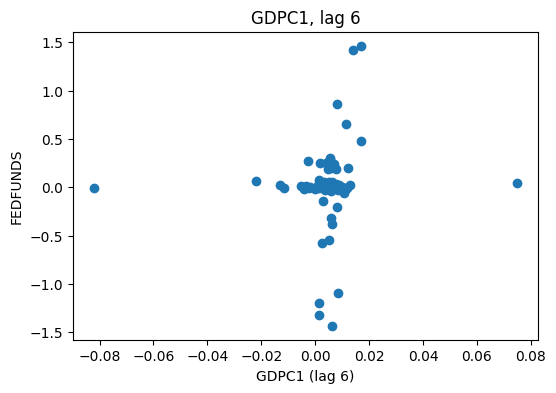

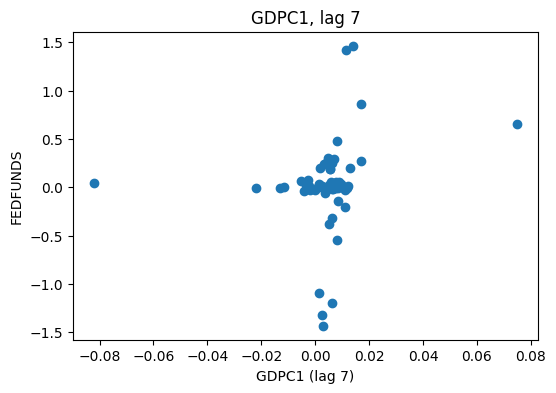

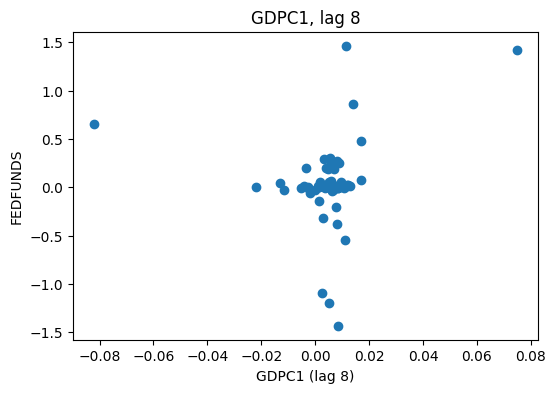

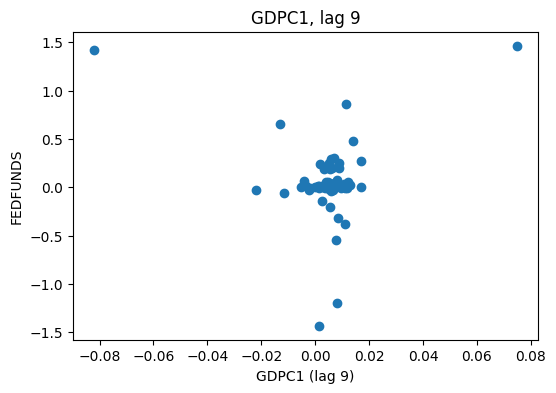

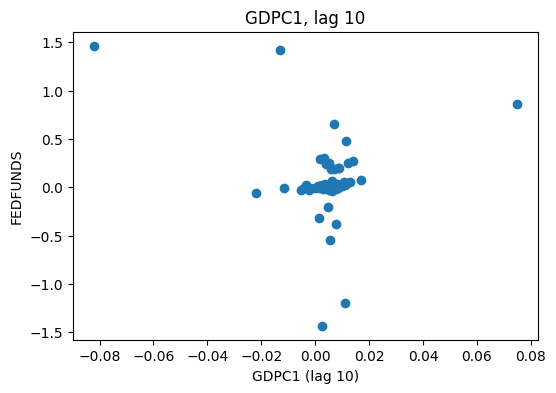

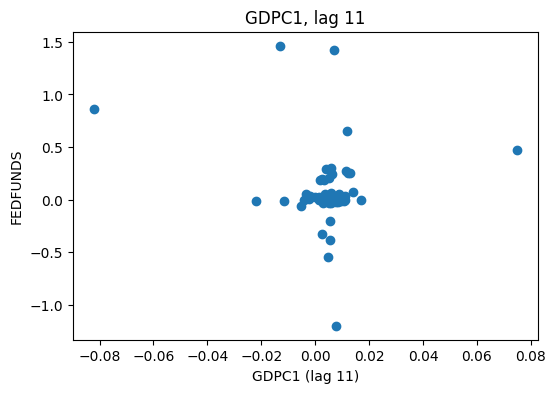

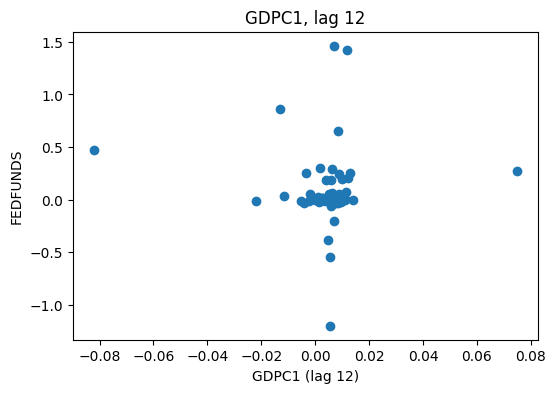

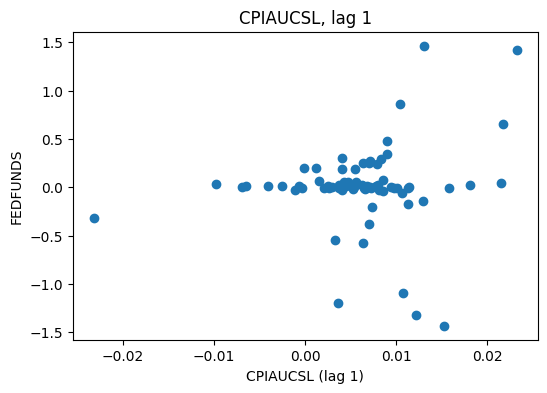

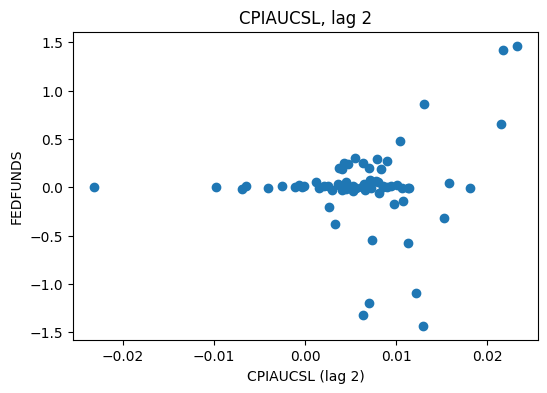

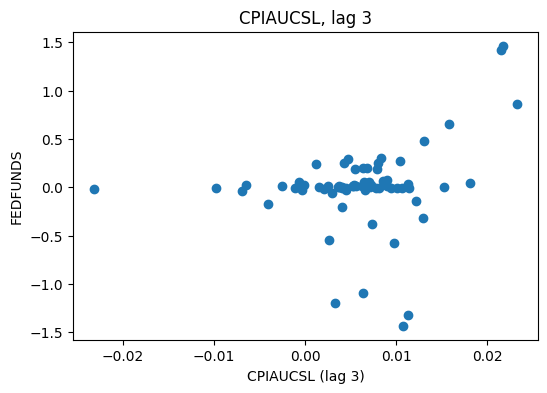

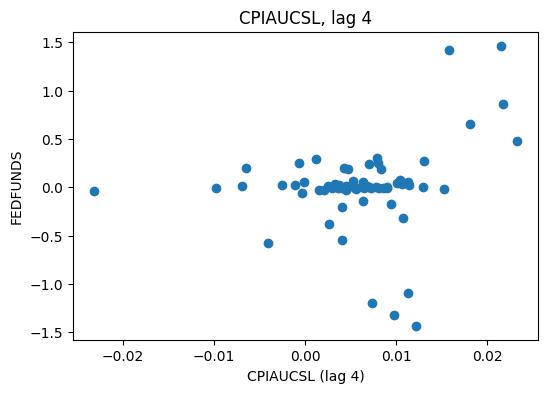

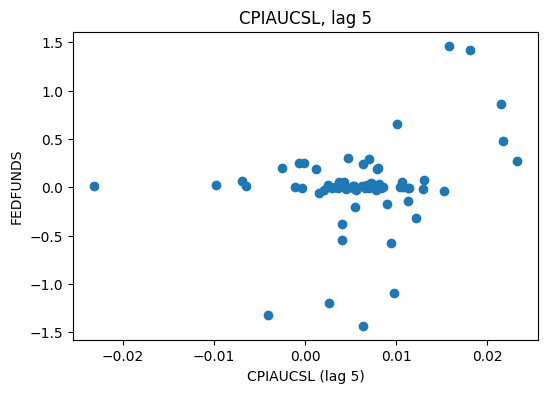

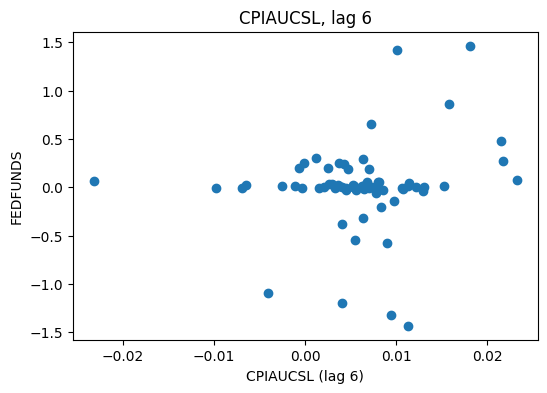

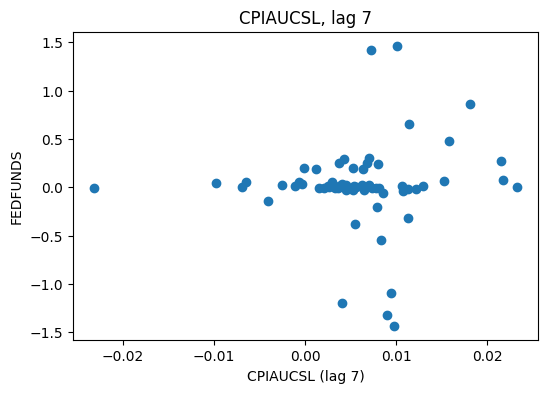

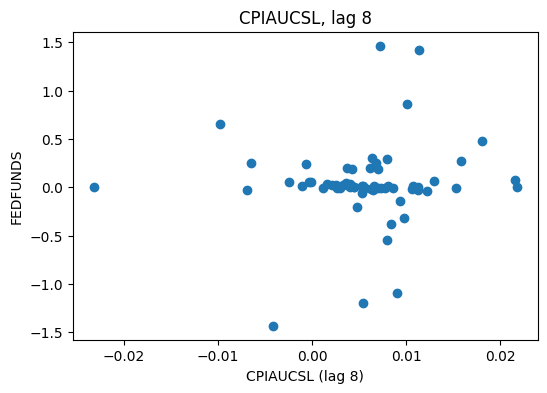

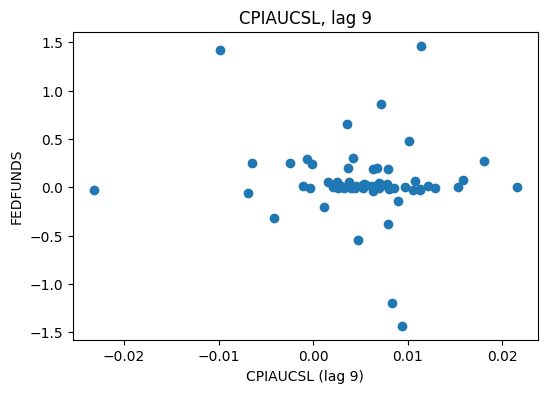

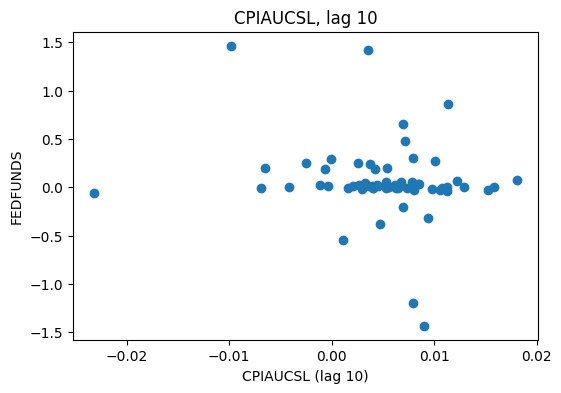

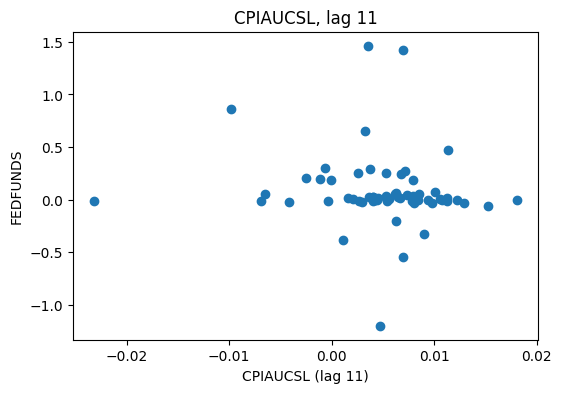

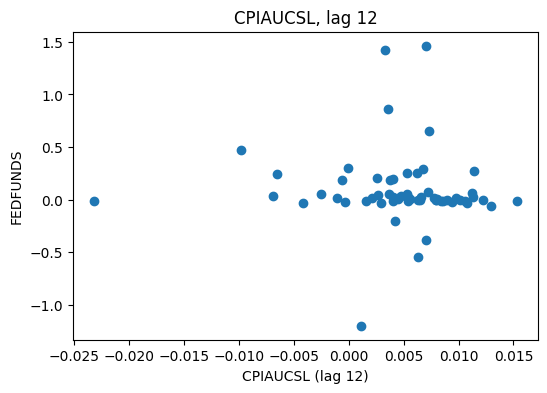

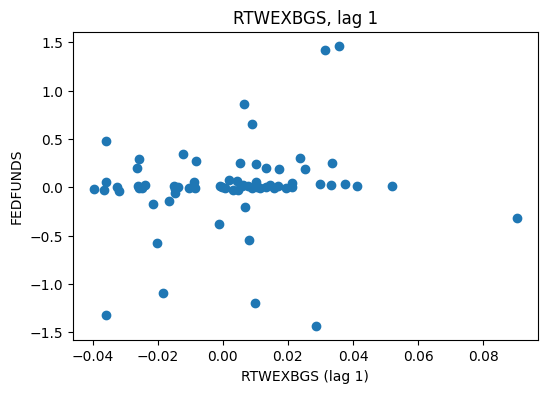

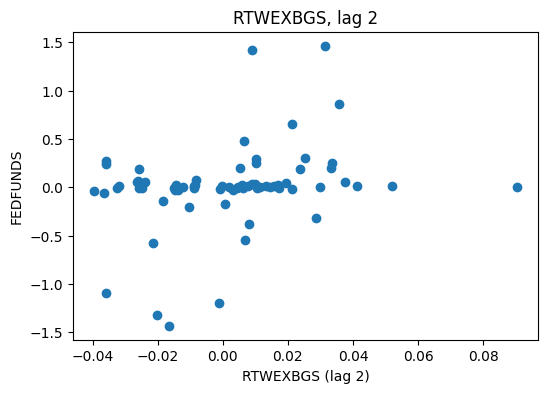

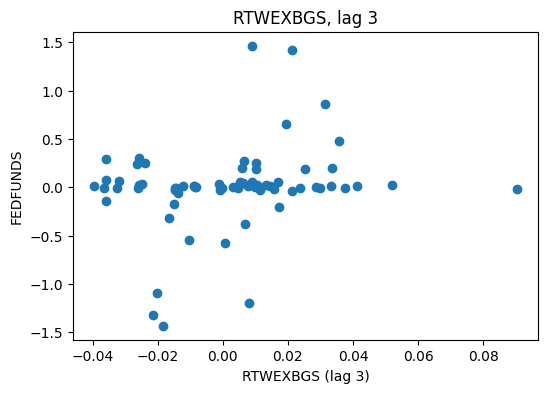

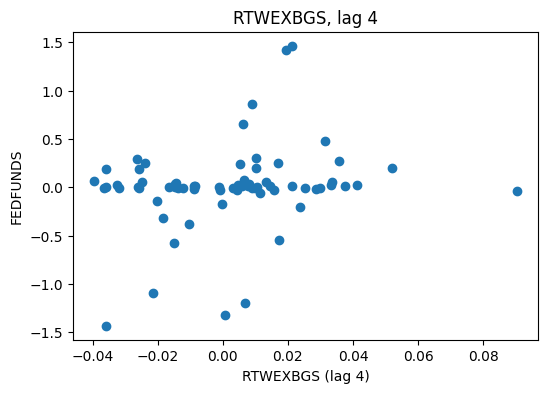

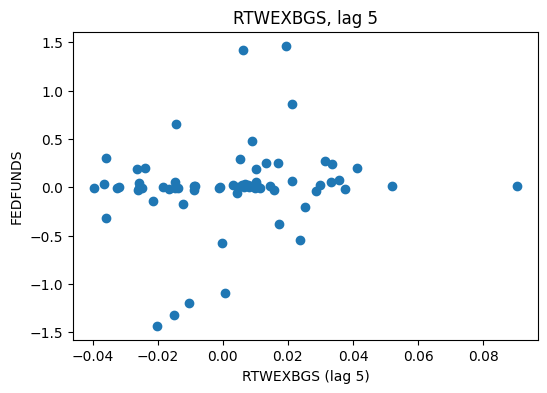

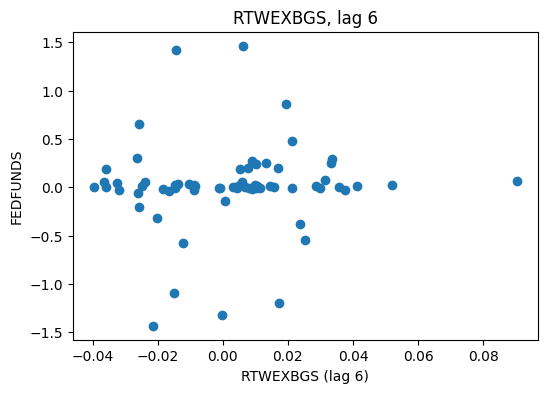

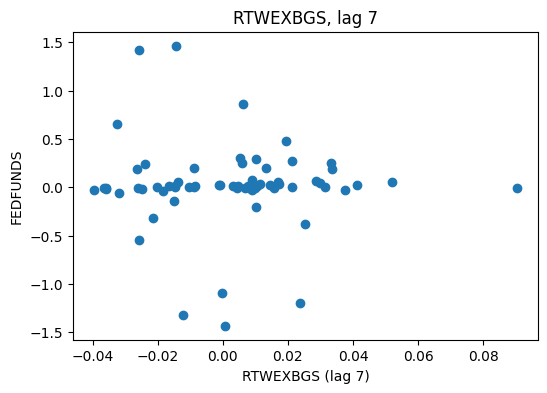

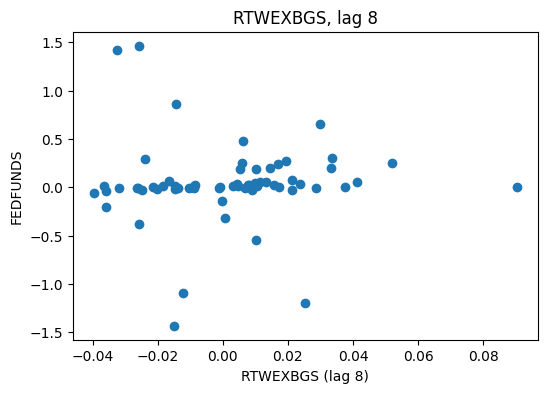

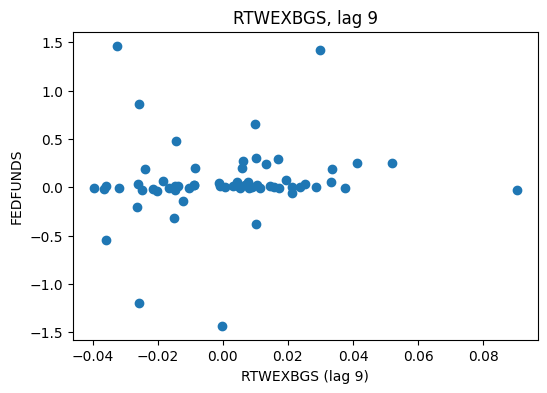

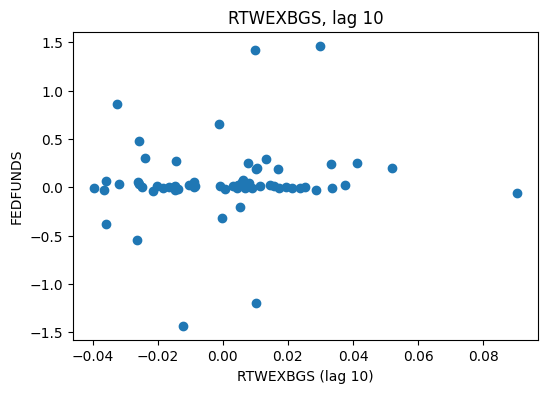

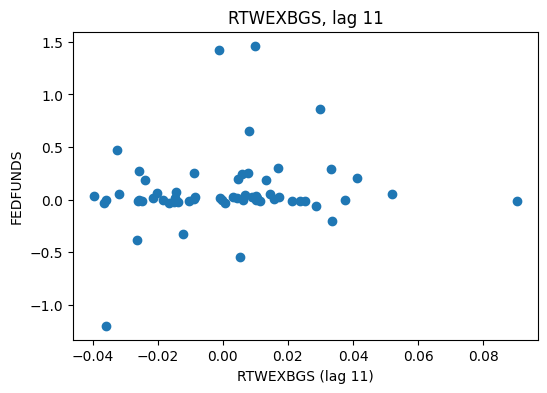

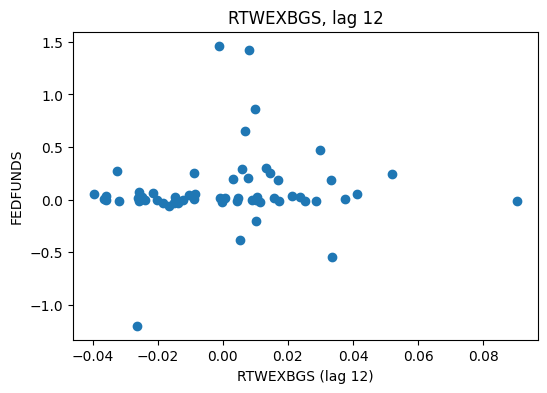

In [108]:
for f in data.columns.drop('FEDFUNDS'):
    for lag in range(1, 13):
        plt.figure(figsize=(6, 4))
        plt.scatter(data[f].shift(lag), data['FEDFUNDS'])
        plt.xlabel(f'{f} (lag {lag})')
        plt.ylabel('FEDFUNDS')
        plt.title(f'{f}, lag {lag}')
        plt.show()

In [109]:
PYSR_NITERATIONS = int(os.getenv('EDA_RATE_PYSR_NITERATIONS', '100'))

def fit_pysr(horizon, max_lag):
    X = pd.DataFrame({
        f'{col}_lag{lag}': data[col].shift(lag)
        for col in data.columns for lag in range(1, max_lag + 1)
    })
    y = data['FEDFUNDS'].shift(1 - horizon).rename('target')
    sample = X.join(y).dropna()
    model = PySRRegressor(
        niterations=PYSR_NITERATIONS,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "sqrt", "log", "sin"],
        nested_constraints={"/": {"+": 0, "-": 0}},
        parallelism="serial", deterministic=True, random_state=42, progress=False, verbosity=0,
        temp_equation_file=True
    )
    return model.fit(sample.drop(columns='target'), sample['target'])

In [110]:
model = fit_pysr(1, 3)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      FEDFUNDS_lag1   
	1         0.230837                                 sin(FEDFUNDS_lag1)   
	2         0.042496                            sin(sin(FEDFUNDS_lag1))   
	3         0.006283                       sin(sin(sin(FEDFUNDS_lag1)))   
	4         0.035419            DTWEXBGS_lag1 + sin(sin(FEDFUNDS_lag1))   
	5         0.122777   sin(FEDFUNDS_lag1 * (1.5140773 - FEDFUNDS_lag3))   
	6         0.384728  sin(FEDFUNDS_lag1 * square(FEDFUNDS_lag3 + -1....   
	7         0.165309  sin(FEDFUNDS_lag1 * square(FEDFUNDS_lag3 + -1....   
	8         0.070689  sin(FEDFUNDS_lag1 * (square(FEDFUNDS_lag3 + -0...   
	9         0.099985  sin(FEDFUNDS_lag1 * (square(FEDFUNDS_lag3 + -0...   
	10        0.061398  1.5575588 * sin(FEDFUNDS_lag1 * ((CPIAUCSL_lag...   
	11        0.039857  sin(((CPIAUCSL_lag2 * 27.321692) + square(((RT...   
	12        0.045385  sin((square((RTWEXBGS_lag2 + ((-0.97430897 + D...   
	13        0.012175  RTWEXBGS_lag2 + (sin((square((GDPC1_lag1 + (FE...   
	14        0.000661  (1.5952463 * sin(((CPIAUCSL_lag2 * 25.68725) +...   
	15  >>>>  0.146188  sin(FEDFUNDS_lag1 * ((CPIAUCSL_lag2 * 31.43933...   
	16        0.014145  DTWEXBGS_lag1 + ((1.626617 - (DTWEXBGS_lag3 * ...   
	17        0.011861  RTWEXBGS_lag1 + ((sin(FEDFUNDS_lag1 * (square(...   
	18        0.006724  (DTWEXBGS_lag1 + ((1.6276729 - (DTWEXBGS_lag3 ...   
	19        0.001305  RTWEXBGS_lag2 + ((1.6276729 - (DTWEXBGS_lag3 *...   
	
	        loss  complexity  
	0   0.128758           1  
	1   0.102217           2  
	2   0.097964           3  
	3   0.097350           4  
	4   0.093963           5  
	5   0.083106           6  
	6   0.056565           7  
	7   0.040641           9  
	8   0.035283          11  
	9   0.028888          13  
	10  0.025550          15  
	11  0.023592          17  
	12  0.021545          19  
	13  0.021027          21  
	14  0.021013          22  
	15  0.018155          23  
	16  0.017649          25  
	17  0.017235          27  
	18  0.017005          29  
	19  0.016982          30  
]

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\mathrm{FEDFUNDS}_{t-1}
\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}{0.040583}
+
0.58368
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\left[
\mathrm{FEDFUNDS}_{t-1}
+
\mathrm{FEDFUNDS}_{t-3}
\left(
0.28488-\mathrm{FEDFUNDS}_{t-1}^{2}
\right)
\right]
\left(
0.53374+
\frac{\mathrm{CPIAUCSL}_{t-1}}{0.018039}
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}{0.017488}
+
0.67015
\right)
\left[
\mathrm{FEDFUNDS}_{t-1}
+
\left(
\mathrm{FEDFUNDS}_{t-1}
\left(
\frac{\mathrm{GDPC1}_{t-2}}{\mathrm{DTWEXBGS}_{t-2}}
-
\mathrm{FEDFUNDS}_{t-1}
\right)
+
\frac{\mathrm{CPIAUCSL}_{t-1}}{0.022338}
-
0.26788
\right)
\left(
\mathrm{FEDFUNDS}_{t-3}
+
\frac{\mathrm{RTWEXBGS}_{t-1}}{0.21649}
-
0.057655
\right)
\right]
$$

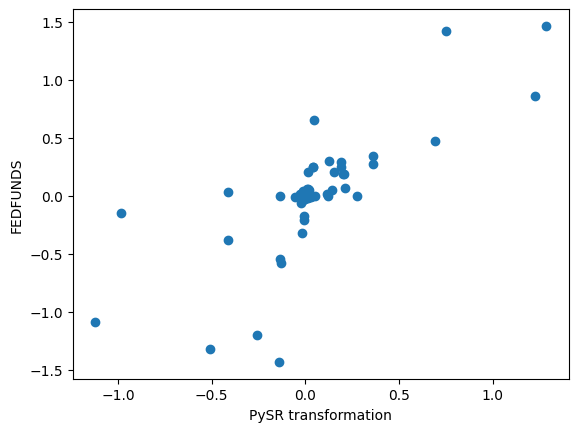

In [111]:
z = data['FEDFUNDS'].shift(1) * (
    data['CPIAUCSL'].shift(1) / 0.040583 + 0.58368
)

plt.scatter(z, data['FEDFUNDS'])
plt.xlabel('PySR transformation')
plt.ylabel('FEDFUNDS')
plt.show()

In [112]:
model = fit_pysr(1, 2)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      FEDFUNDS_lag1   
	1         0.228120                                 sin(FEDFUNDS_lag1)   
	2         0.042414                            sin(sin(FEDFUNDS_lag1))   
	3         0.006738                       sin(sin(sin(FEDFUNDS_lag1)))   
	4         0.034865            sin(sin(FEDFUNDS_lag1)) + DTWEXBGS_lag1   
	5         0.047938       sin(FEDFUNDS_lag1 - 0.46785936) + 0.40475252   
	6         0.016148  sin((CPIAUCSL_lag1 * 142.86113) * sin(FEDFUNDS...   
	7         0.070954  sin(FEDFUNDS_lag1 + square(sin(square(square(F...   
	8         0.069835  sin(FEDFUNDS_lag1 + sin((CPIAUCSL_lag1 * 141.9...   
	9         0.046417  sin(FEDFUNDS_lag1 + ((FEDFUNDS_lag1 * (GDPC1_l...   
	10        0.068469  sin(sin(FEDFUNDS_lag1) + (((CPIAUCSL_lag1 - GD...   
	11        0.037205  sin(((FEDFUNDS_lag1 * 63.190823) * (CPIAUCSL_l...   
	12        0.028795  sin((((CPIAUCSL_lag1 - GDPC1_lag1) * sin(FEDFU...   
	13        0.105181  FEDFUNDS_lag1 + sin(((CPIAUCSL_lag1 * 57.78418...   
	14        0.123267  sin(FEDFUNDS_lag1 - (square(square(-0.35679495...   
	15        0.081317  (FEDFUNDS_lag1 * (CPIAUCSL_lag1 * 33.450653)) ...   
	16        0.075839  sin(FEDFUNDS_lag1 * (CPIAUCSL_lag1 * 47.264736...   
	17        0.026782  sin((((CPIAUCSL_lag1 * 46.452892) - FEDFUNDS_l...   
	18        0.061647  (sin((FEDFUNDS_lag2 * ((CPIAUCSL_lag1 * 50.313...   
	19        0.034284  sin((((CPIAUCSL_lag1 * 48.285427) - (sin(FEDFU...   
	20  >>>>  0.062509  sin((CPIAUCSL_lag1 * FEDFUNDS_lag1) * 72.005) ...   
	21        0.021347  sin((FEDFUNDS_lag2 * ((CPIAUCSL_lag1 * 58.2635...   
	22        0.030022  sin(FEDFUNDS_lag1 + (((((CPIAUCSL_lag2 * 9.664...   
	23        0.018328  (sin((FEDFUNDS_lag2 * ((sin(sin(-0.13325243 - ...   
	24        0.059001  sin(FEDFUNDS_lag1 * (CPIAUCSL_lag1 * 74.855286...   
	25        0.015673  sin((RTWEXBGS_lag2 + FEDFUNDS_lag1) * (CPIAUCS...   
	26        0.010841  sin((FEDFUNDS_lag1 + DTWEXBGS_lag2) * (CPIAUCS...   
	
	        loss  complexity  
	0   0.128570           1  
	1   0.102345           2  
	2   0.098095           3  
	3   0.097437           4  
	4   0.094098           5  
	5   0.089693           6  
	6   0.088257           7  
	7   0.082212           8  
	8   0.076666           9  
	9   0.073189          10  
	10  0.068345          11  
	11  0.065849          12  
	12  0.063980          13  
	13  0.057593          14  
	14  0.050913          15  
	15  0.046937          16  
	16  0.043509          17  
	17  0.042359          18  
	18  0.039827          19  
	19  0.038485          20  
	20  0.033962          22  
	21  0.033245          23  
	22  0.032261          24  
	23  0.031676          25  
	24  0.029861          26  
	25  0.028939          28  
	26  0.028319          30  
]

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\mathrm{FEDFUNDS}_{t-1}
+
\left(
0.21646
-
59.267\,\mathrm{GDPC1}_{t-2}
\right)
\mathrm{FEDFUNDS}_{t-1}^{2}
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\mathrm{FEDFUNDS}_{t-1}
\left(
0.57757
+
24.428\,\mathrm{CPIAUCSL}_{t-1}
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\left(
\mathrm{CPIAUCSL}_{t-2}
+
\mathrm{FEDFUNDS}_{t-1}
\right)
\left[
\mathrm{DTWEXBGS}_{t-1}
\frac{\mathrm{FEDFUNDS}_{t-2}}{\sqrt{0.19043}}
+
\frac{\mathrm{GDPC1}_{t-2}}{-0.029473}
-
\frac{\mathrm{RTWEXBGS}_{t-2}}{\mathrm{DTWEXBGS}_{t-2}}
\left(
0.59841
+
\frac{
\mathrm{FEDFUNDS}_{t-1}\mathrm{RTWEXBGS}_{t-1}
}{0.14828}
\right)
\right]^2
+
\mathrm{RTWEXBGS}_{t-2}
$$

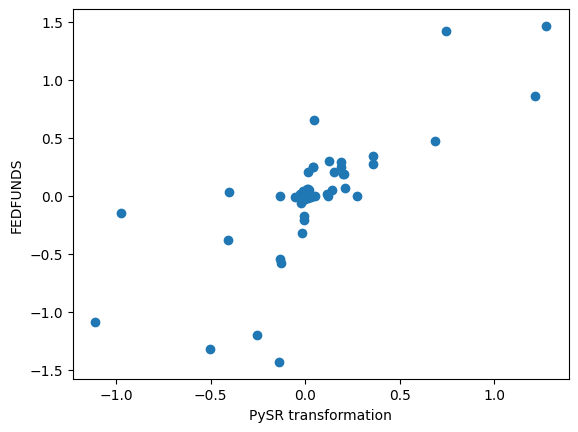

In [113]:
z = data['FEDFUNDS'].shift(1) * (
    0.57757 + 24.428 * data['CPIAUCSL'].shift(1)
)

plt.scatter(z, data['FEDFUNDS'])
plt.xlabel('PySR transformation')
plt.ylabel('FEDFUNDS')
plt.show()

### Выбранные преобразования признаков для FEDFUNDS

По результатам PySR наиболее устойчиво повторяются следующие преобразования:

1. **Авторегрессионный лаг FEDFUNDS**
$$
\mathrm{FEDFUNDS}_{t-1}
$$

2. **Взаимодействие FEDFUNDS и CPI**
$$
\mathrm{FEDFUNDS}_{t-1}\cdot\mathrm{CPIAUCSL}_{t-1}
$$

3. **Квадрат FEDFUNDS**
$$
\mathrm{FEDFUNDS}_{t-1}^{2}
$$

4. **Взаимодействие GDP с квадратом FEDFUNDS**
$$
\mathrm{GDPC1}_{t-2}\cdot\mathrm{FEDFUNDS}_{t-1}^{2}
$$

5. **Отношение валютных индексов**
$$
\frac{\mathrm{RTWEXBGS}_{t-2}}
{\mathrm{DTWEXBGS}_{t-2}}
$$

6. **Отношение GDP к DTWEXBGS**
$$
\frac{\mathrm{GDPC1}_{t-2}}
{\mathrm{DTWEXBGS}_{t-2}}
$$

7. **Лаг DTWEXBGS**
$$
\mathrm{DTWEXBGS}_{t-1}
$$

# для предикта на 2 квартала вперед

In [114]:
model = fit_pysr(2, 3)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      RTWEXBGS_lag1   
	1         0.255147                                 sin(FEDFUNDS_lag1)   
	2         0.071466                            sin(sin(FEDFUNDS_lag1))   
	3         0.038698                      sin(FEDFUNDS_lag1 * 1.873312)   
	4         0.022460                sin(sin(FEDFUNDS_lag1 * 1.8473022))   
	5         0.053293         sin(FEDFUNDS_lag1 * 1.8285031) * 0.7322013   
	6         0.055319  (RTWEXBGS_lag1 * 6.0421658) + sin(sin(FEDFUNDS...   
	7         0.029150  (RTWEXBGS_lag1 * 5.930788) + sin(sin(sin(FEDFU...   
	8         0.028780  sin(sin(FEDFUNDS_lag1)) + ((RTWEXBGS_lag1 - GD...   
	9         0.083526  sin(FEDFUNDS_lag1) + ((CPIAUCSL_lag1 * 5.33739...   
	10        0.038862  ((CPIAUCSL_lag1 / (RTWEXBGS_lag3 / RTWEXBGS_la...   
	11        0.003340  ((CPIAUCSL_lag1 * 4.7263074) / (RTWEXBGS_lag3 ...   
	12        0.029650  ((RTWEXBGS_lag1 + (CPIAUCSL_lag1 * (CPIAUCSL_l...   
	13        0.044788  sin(sin(sin(FEDFUNDS_lag1))) + ((RTWEXBGS_lag1...   
	14        0.033846  ((RTWEXBGS_lag1 + ((RTWEXBGS_lag3 + CPIAUCSL_l...   
	15        0.052799  ((((RTWEXBGS_lag3 + CPIAUCSL_lag2) * (CPIAUCSL...   
	16        0.082642  ((((CPIAUCSL_lag2 + RTWEXBGS_lag3) * ((CPIAUCS...   
	17        0.039110  ((((CPIAUCSL_lag2 + RTWEXBGS_lag3) * ((CPIAUCS...   
	18        0.023512  ((((((CPIAUCSL_lag2 / DTWEXBGS_lag1) - FEDFUND...   
	19        0.060840  sin(FEDFUNDS_lag1 * 1.7350576) + ((RTWEXBGS_la...   
	20        0.019362  ((((((CPIAUCSL_lag2 / DTWEXBGS_lag1) - FEDFUND...   
	21        0.018921  ((((RTWEXBGS_lag3 + CPIAUCSL_lag2) * ((CPIAUCS...   
	22        0.005055  (((((CPIAUCSL_lag2 + RTWEXBGS_lag3) * ((CPIAUC...   
	23  >>>>  0.096993  (CPIAUCSL_lag1 / (RTWEXBGS_lag3 / (RTWEXBGS_la...   
	24        0.060211  (((CPIAUCSL_lag1 / (RTWEXBGS_lag3 / (RTWEXBGS_...   
	25        0.006004  (DTWEXBGS_lag1 + (((RTWEXBGS_lag3 + CPIAUCSL_l...   
	26        0.012439  (((CPIAUCSL_lag2 / (RTWEXBGS_lag3 / RTWEXBGS_l...   
	27        0.015243  (((CPIAUCSL_lag2 / (RTWEXBGS_lag3 / RTWEXBGS_l...   
	28        0.030739  (DTWEXBGS_lag1 + ((((DTWEXBGS_lag3 + ((DTWEXBG...   
	
	        loss  complexity  
	0   0.193817           1  
	1   0.150170           2  
	2   0.139813           3  
	3   0.134506           4  
	4   0.131518           5  
	5   0.124693           6  
	6   0.117982           7  
	7   0.114593           8  
	8   0.111342           9  
	9   0.102419          10  
	10  0.098516          11  
	11  0.098187          12  
	12  0.095319          13  
	13  0.091144          14  
	14  0.088110          15  
	15  0.083579          16  
	16  0.076950          17  
	17  0.073998          18  
	18  0.072279          19  
	19  0.068012          20  
	20  0.066708          21  
	21  0.065458          22  
	22  0.065128          23  
	23  0.059107          24  
	24  0.055654          25  
	25  0.054989          27  
	26  0.054310          28  
	27  0.053488          29  
	28  0.051869          30  
]

In [115]:
model = fit_pysr(2, 2)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      DTWEXBGS_lag1   
	1         0.246693                                 sin(FEDFUNDS_lag1)   
	2         0.071125                            sin(sin(FEDFUNDS_lag1))   
	3         0.030428                       sin(sin(sin(FEDFUNDS_lag1)))   
	4         0.019715            DTWEXBGS_lag1 + sin(sin(FEDFUNDS_lag1))   
	5         0.055577         sin(FEDFUNDS_lag1 * 1.8028059) * 0.7060436   
	6         0.100139  sin((1.2881721 - sin(FEDFUNDS_lag1)) * FEDFUND...   
	7         0.118516  (1.0562437 - sin(-1.1614995 / GDPC1_lag1)) * F...   
	8         0.069209  sin((1.2789637 - sin(0.8502898 / DTWEXBGS_lag2...   
	9         0.040107  sin((sin(0.85012126 / DTWEXBGS_lag2) - 1.23893...   
	10        0.000348  sin((sin(0.85012126 / sin(DTWEXBGS_lag2)) - 1....   
	11        0.090972  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.06...   
	12        0.138241  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	13        0.112508  (square(CPIAUCSL_lag2) / (0.0752587 * DTWEXBGS...   
	14        0.000543  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * sin(...   
	15  >>>>  0.130061  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	16        0.000010  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * sin(...   
	17        0.026736  sin(0.07614144 - ((sin(0.85013646 / DTWEXBGS_l...   
	18        0.001528  sin(0.07614144 - ((FEDFUNDS_lag1 + -0.11110975...   
	19        0.032582  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	20        0.001891  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	21        0.016602  sin((GDPC1_lag1 / 0.23082507) + ((DTWEXBGS_lag...   
	22        0.000968  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	23        0.016146  ((square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.0...   
	24        0.000829  (square(CPIAUCSL_lag2) / (DTWEXBGS_lag1 * 0.07...   
	25        0.019491  (sin((GDPC1_lag1 / 0.2089848) + (((FEDFUNDS_la...   
	26        0.006735  (sin((((DTWEXBGS_lag1 + RTWEXBGS_lag2) - (sin(...   
	
	        loss  complexity  
	0   0.191341           1  
	1   0.149510           2  
	2   0.139246           3  
	3   0.135073           4  
	4   0.132436           5  
	5   0.125276           6  
	6   0.113339           7  
	7   0.100672           8  
	8   0.093940           9  
	9   0.086699          11  
	10  0.086669          12  
	11  0.079132          13  
	12  0.068916          14  
	13  0.055029          16  
	14  0.054999          17  
	15  0.048292          18  
	16  0.048291          19  
	17  0.047017          20  
	18  0.046945          21  
	19  0.045441          22  
	20  0.045355          23  
	21  0.044608          24  
	22  0.044565          25  
	23  0.043851          26  
	24  0.043815          27  
	25  0.042969          28  
	26  0.042394          30  
]

$$
\mathrm{FEDFUNDS}_{t-1}
$$

$$
\frac{\mathrm{FEDFUNDS}_{t-1}}{\mathrm{GDPC1}_{t-1}}
$$

$$
\mathrm{FEDFUNDS}_{t-1}\cdot\mathrm{CPIAUCSL}_{t-1}
$$

$$
\mathrm{FEDFUNDS}_{t-1}^{2}
$$

$$
\mathrm{FEDFUNDS}_{t-3}^{2}
$$

$$
\mathrm{CPIAUCSL}_{t-1}\cdot\mathrm{CPIAUCSL}_{t-2}
$$

$$
\left(\mathrm{CPIAUCSL}_{t-1}\cdot\mathrm{CPIAUCSL}_{t-2}\right)^2
$$

$$
\frac{\mathrm{GDPC1}_{t-1}}{\mathrm{DTWEXBGS}_{t-1}}
$$

$$
\mathrm{DTWEXBGS}_{t-2}\cdot\mathrm{FEDFUNDS}_{t-1}
$$

$$
\mathrm{RTWEXBGS}_{t-1}
$$

$$
\mathrm{DTWEXBGS}_{t-1}
$$

# Для предикта на 3 квартала вперед

In [116]:
model = fit_pysr(3, 3)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      RTWEXBGS_lag1   
	1         6.055324e-07                                 sin(RTWEXBGS_lag1)   
	2         1.069630e-01                         FEDFUNDS_lag1 * 0.34807786   
	3         1.212318e-02                   square(CPIAUCSL_lag1) * 1086.095   
	4         8.436741e-02           square(square(CPIAUCSL_lag1 * 41.90519))   
	5         1.369586e-01  (square(CPIAUCSL_lag2) * 16.543625) / DTWEXBGS...   
	6         1.388086e-04  sin(square(CPIAUCSL_lag2) / DTWEXBGS_lag1) * 1...   
	7         7.945296e-02  sin(GDPC1_lag3 / DTWEXBGS_lag1) * (CPIAUCSL_la...   
	8         8.411334e-02  sin(GDPC1_lag3 / DTWEXBGS_lag1) * square(CPIAU...   
	9         1.754330e-06  square(CPIAUCSL_lag1 * 54.620285) * sin(GDPC1_...   
	10        8.158442e-02  sin((CPIAUCSL_lag2 / DTWEXBGS_lag1) / 0.638525...   
	11        1.118514e-05  sin((CPIAUCSL_lag2 / DTWEXBGS_lag1) / 0.638525...   
	12        4.459020e-02  (sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * 0.623285...   
	13        5.487627e-03  square(CPIAUCSL_lag1 * -54.997875) * (sin(CPIA...   
	14        4.596152e-02  sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * 0.6257099...   
	15        7.380594e-04  (sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * 0.625709...   
	16        5.717423e-02  (sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * 0.609735...   
	17        2.116518e-02  (sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * 0.610224...   
	18        2.472716e-02  ((CPIAUCSL_lag1 * ((CPIAUCSL_lag2 / RTWEXBGS_l...   
	19        3.693276e-02  ((CPIAUCSL_lag1 / RTWEXBGS_lag2) + (2.3602824 ...   
	20        9.224497e-04  sin((((CPIAUCSL_lag1 / RTWEXBGS_lag2) + 2.3602...   
	21  >>>>  1.118766e-01  sin(CPIAUCSL_lag2 / (-0.5888021 * DTWEXBGS_lag...   
	22        9.401025e-03  ((CPIAUCSL_lag1 * ((CPIAUCSL_lag2 / RTWEXBGS_l...   
	23        6.395354e-05  (sin(CPIAUCSL_lag2 / (DTWEXBGS_lag1 * -0.59254...   
	24        8.252861e-02  ((FEDFUNDS_lag1 + -2.7686486) * ((((CPIAUCSL_l...   
	
	        loss  complexity  
	0   0.198173           1  
	1   0.198173           2  
	2   0.178070           3  
	3   0.175924           4  
	4   0.161691           5  
	5   0.140995           6  
	6   0.140976           7  
	7   0.130208           8  
	8   0.119704           9  
	9   0.119704          10  
	10  0.110326          11  
	11  0.110324          12  
	12  0.105513          13  
	13  0.104936          14  
	14  0.100222          15  
	15  0.100074          17  
	16  0.094513          18  
	17  0.090595          20  
	18  0.086224          22  
	19  0.080085          24  
	20  0.080011          25  
	21  0.071542          26  
	22  0.070209          28  
	23  0.070205          29  
	24  0.064644          30  
]

In [117]:
model = fit_pysr(3, 2)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      RTWEXBGS_lag1   
	1         6.657822e-07                                 sin(RTWEXBGS_lag1)   
	2         1.056683e-01                         FEDFUNDS_lag1 * 0.34494567   
	3         1.253372e-02                 square(CPIAUCSL_lag1 * -32.864758)   
	4         8.516768e-02         square(square(CPIAUCSL_lag1) * -1756.1011)   
	5         7.247525e-02  square(CPIAUCSL_lag2 * (CPIAUCSL_lag1 * 2148.6...   
	6         6.273796e-02  (CPIAUCSL_lag1 * 951.94183) * (RTWEXBGS_lag2 +...   
	7         9.438697e-02  sin(CPIAUCSL_lag1 / RTWEXBGS_lag1) * (CPIAUCSL...   
	8         1.111127e-01  square(CPIAUCSL_lag1 * 57.54157) * sin(CPIAUCS...   
	9         6.672569e-02  ((sin(0.018913431 / RTWEXBGS_lag1) * 3188.5764...   
	10        1.415677e-02  sin(0.018903565 / RTWEXBGS_lag1) * ((CPIAUCSL_...   
	11        4.576767e-02  (FEDFUNDS_lag1 * 0.25353715) + ((CPIAUCSL_lag1...   
	12        4.009215e-05  (((CPIAUCSL_lag1 * 2974.9321) * CPIAUCSL_lag1)...   
	13        1.144564e-02  (((CPIAUCSL_lag1 * (2974.9321 * CPIAUCSL_lag1)...   
	14        3.833552e-03  ((sin(0.018953145 / RTWEXBGS_lag1) * (CPIAUCSL...   
	15        2.629700e-02  (-2975.1807 * ((sin(0.018953145 / RTWEXBGS_lag...   
	16        9.430200e-03  ((FEDFUNDS_lag1 * 0.28882483) - DTWEXBGS_lag1)...   
	17        4.128654e-04  (FEDFUNDS_lag1 * 0.25403187) + (((sin(GDPC1_la...   
	18        4.462979e-02  ((((-0.47247943 / RTWEXBGS_lag2) + -32.95279) ...   
	19        2.337357e-04  (((((-0.47327077 / RTWEXBGS_lag2) + -32.952618...   
	20  >>>>  9.922995e-02  ((FEDFUNDS_lag1 * 0.30987474) + (((-0.4566762 ...   
	21        2.831081e-02  log((FEDFUNDS_lag1 * 0.27659795) + 0.9135162) ...   
	22        3.213302e-02  ((0.38188422 - (DTWEXBGS_lag2 / 0.10379927)) *...   
	23        1.552968e-02  ((((sin(0.29626715 / RTWEXBGS_lag1) + 0.604853...   
	24        9.281931e-02  ((0.38188422 - (DTWEXBGS_lag2 / 0.10379927)) *...   
	25        6.922362e-02  (((((-0.4219019 / RTWEXBGS_lag2) + -32.963966)...   
	
	        loss  complexity  
	0   0.195259           1  
	1   0.195259           2  
	2   0.175679           3  
	3   0.173491           4  
	4   0.159327           5  
	5   0.148188           6  
	6   0.139177           7  
	7   0.126641           8  
	8   0.113323           9  
	9   0.106008          10  
	10  0.103049          12  
	11  0.094035          14  
	12  0.094031          15  
	13  0.092961          16  
	14  0.092606          17  
	15  0.090202          18  
	16  0.088517          20  
	17  0.088480          21  
	18  0.084618          22  
	19  0.084599          23  
	20  0.076607          24  
	21  0.074468          25  
	22  0.072114          26  
	23  0.071002          27  
	24  0.064709          28  
	25  0.060381          29  
]

$$
\mathrm{RTWEXBGS}_{t-1}
$$

$$
\mathrm{RTWEXBGS}_{t-2}
$$

$$
\mathrm{FEDFUNDS}_{t-1}
$$

$$
\mathrm{CPIAUCSL}_{t-1}^{2}
$$

$$
\mathrm{CPIAUCSL}_{t-1}^{4}
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
\right)^2
$$

$$
\mathrm{CPIAUCSL}_{t-1}
\left(
\mathrm{RTWEXBGS}_{t-2}
+
\mathrm{CPIAUCSL}_{t-1}
\right)
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}
+
\mathrm{RTWEXBGS}_{t-2}
\right)
\mathrm{CPIAUCSL}_{t-1}^{2}
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}
-
\mathrm{FEDFUNDS}_{t-1}
\right)^2
$$

$$
\mathrm{FEDFUNDS}_{t-1}
\mathrm{RTWEXBGS}_{t-2}
$$

$$
\frac{\mathrm{RTWEXBGS}_{t-3}}
{\mathrm{DTWEXBGS}_{t-2}}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-3}}
$$

$$
\frac{\mathrm{GDPC1}_{t-2}}
{\left(
\mathrm{RTWEXBGS}_{t-3}/\mathrm{DTWEXBGS}_{t-2}
\right)^2}
$$

# Для предикта на 4 квратала вперед

In [118]:
model = fit_pysr(4, 3)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      RTWEXBGS_lag1   
	1         5.560751e-02                       0.0001943564 / RTWEXBGS_lag3   
	2         1.669538e-07                  0.0001943564 / sin(RTWEXBGS_lag3)   
	3         2.588167e-02    RTWEXBGS_lag1 + (0.00019575306 / RTWEXBGS_lag3)   
	4         1.655020e-01    CPIAUCSL_lag2 / sin(0.79479903 / CPIAUCSL_lag2)   
	5         1.031897e-02  CPIAUCSL_lag2 / sin(0.7947896 / sin(CPIAUCSL_l...   
	6         1.783155e-02  sqrt(square(CPIAUCSL_lag2 / sin(0.79479903 / C...   
	7         1.049942e-02  sqrt(square(CPIAUCSL_lag2 / sin(0.7947896 / si...   
	8         1.778568e-02  sqrt(square(CPIAUCSL_lag2 / sin(0.79479903 / C...   
	9         5.578799e-03  sqrt(square(CPIAUCSL_lag2 / sin(0.79478294 / s...   
	10        9.496125e-03  sqrt(square(CPIAUCSL_lag2 / sin(0.79479903 / C...   
	11        2.070448e-02  square(square(sin(square((GDPC1_lag3 / 0.02811...   
	12        2.022740e-02  square(square(square(sin(square(((GDPC1_lag3 /...   
	13        2.389919e-02  square(square(sin(square((GDPC1_lag3 / 0.02825...   
	14        2.458553e-02  square(square(square(sin(square(((GDPC1_lag3 /...   
	15        2.995448e-02  (square(square(sin(square(((CPIAUCSL_lag2 / 0....   
	16        1.041860e-02  square(square(square(sin(square((GDPC1_lag3 / ...   
	17  >>>>  9.413196e-02  square(square(sin(square((GDPC1_lag3 / 0.02827...   
	18        1.018620e-02  ((0.021750722 * CPIAUCSL_lag3) / RTWEXBGS_lag3...   
	19        2.600358e-02  ((CPIAUCSL_lag1 / RTWEXBGS_lag3) * 0.022653148...   
	20        6.549195e-03  (square(square(sin(square((GDPC1_lag3 / 0.0282...   
	21        6.180602e-03  ((square(square(sin(square((GDPC1_lag3 / 0.028...   
	22        2.420834e-02  (square(square(sin(square((CPIAUCSL_lag2 / 0.0...   
	23        7.382435e-03  square((0.032611173 - square(sin(square(0.1598...   
	24        1.510744e-02  ((CPIAUCSL_lag3 + CPIAUCSL_lag3) * (CPIAUCSL_l...   
	25        1.906808e-03  ((CPIAUCSL_lag3 + CPIAUCSL_lag3) * (CPIAUCSL_l...   
	
	        loss  complexity  
	0   0.200828           1  
	1   0.179690           3  
	2   0.179690           4  
	3   0.175099           5  
	4   0.148391           6  
	5   0.146868           7  
	6   0.144272           8  
	7   0.142765           9  
	8   0.140249          10  
	9   0.139468          11  
	10  0.138150          12  
	11  0.135319          13  
	12  0.132610          14  
	13  0.129478          15  
	14  0.126333          16  
	15  0.122605          17  
	16  0.121335          18  
	17  0.110434          19  
	18  0.109315          20  
	19  0.106509          21  
	20  0.105123          23  
	21  0.104475          24  
	22  0.101977          25  
	23  0.100482          27  
	24  0.098975          28  
	25  0.098599          30  
]

In [119]:
model = fit_pysr(4, 2)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      RTWEXBGS_lag1   
	1         0.015774                          CPIAUCSL_lag2 * 10.898893   
	2         0.049431                 square(CPIAUCSL_lag1 * -30.520868)   
	3         0.048444          square(square(CPIAUCSL_lag1 * 40.024067))   
	4         0.098134       sin(square(square(CPIAUCSL_lag2) * 3226.91))   
	5         0.059370  sin(square(square(square(CPIAUCSL_lag1 * 59.35...   
	6         0.094404  sin(((CPIAUCSL_lag2 / RTWEXBGS_lag1) * CPIAUCS...   
	7         0.000010  sin((CPIAUCSL_lag2 * 29.122044) * (CPIAUCSL_la...   
	8         0.283966  sin(square(square(square(square(CPIAUCSL_lag1 ...   
	9         0.005979  sin(-2.5434833 * square(square(square(square(C...   
	10        0.030846  sin(square(square(CPIAUCSL_lag1) + square(squa...   
	11        0.011506  sin(square((CPIAUCSL_lag1 / DTWEXBGS_lag2) / -...   
	12        0.012749  sin(((CPIAUCSL_lag1 * 0.2754028) + RTWEXBGS_la...   
	13        0.016997  (sin(((CPIAUCSL_lag1 * 0.27956685) + RTWEXBGS_...   
	14        0.117797  (CPIAUCSL_lag1 / sin(4.004365 / CPIAUCSL_lag2)...   
	15        0.066116  (CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / DTWEXBGS...   
	16        0.013527  (CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / sin(DTWE...   
	17  >>>>  0.215753  ((CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / DTWEXBG...   
	18        0.020503  (sin(CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / DTWE...   
	19        0.063425  ((CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / DTWEXBG...   
	20        0.001606  ((CPIAUCSL_lag1 / sin(sin((CPIAUCSL_lag2 / DTW...   
	21        0.029406  ((CPIAUCSL_lag1 / sin((CPIAUCSL_lag2 / DTWEXBG...   
	22        0.001722  1.4481957 * (((CPIAUCSL_lag1 / sin(sin((CPIAUC...   
	23        0.009718  1.4481957 * (((CPIAUCSL_lag1 / sin((CPIAUCSL_l...   
	
	        loss  complexity  
	0   0.198296           1  
	1   0.192138           3  
	2   0.182871           4  
	3   0.174223           5  
	4   0.157938           6  
	5   0.148834           7  
	6   0.135427           8  
	7   0.135425           9  
	8   0.101947          10  
	9   0.100735          12  
	10  0.097675          13  
	11  0.095453          15  
	12  0.093050          17  
	13  0.089940          19  
	14  0.079946          20  
	15  0.070044          22  
	16  0.069102          23  
	17  0.055692          24  
	18  0.054562          25  
	19  0.051209          26  
	20  0.051127          27  
	21  0.049645          28  
	22  0.049560          29  
	23  0.049080          30  
]

$$
\mathrm{CPIAUCSL}_{t-2}
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-3}}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{
\mathrm{CPIAUCSL}_{t-1}\mathrm{CPIAUCSL}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-1}
}
$$

$$
\frac{
\mathrm{GDPC1}_{t-3}
}{
\mathrm{RTWEXBGS}_{t-2}
}
$$

$$
\frac{
\mathrm{CPIAUCSL}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-1}
}
$$

$$
\mathrm{CPIAUCSL}_{t-1}^{2}
$$

$$
\mathrm{CPIAUCSL}_{t-1}\mathrm{CPIAUCSL}_{t-2}
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}
-
\mathrm{FEDFUNDS}_{t-1}
\right)^2
$$

$$
\frac{
\mathrm{GDPC1}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-1}
}
$$

$$
\left(
\mathrm{RTWEXBGS}_{t-1}
+
\mathrm{CPIAUCSL}_{t-2}
\right)
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}
+
\mathrm{RTWEXBGS}_{t-2}
\right)\mathrm{CPIAUCSL}_{t-1}^{2}
$$

# Для предикта на 5 кварталов вперед

In [120]:
model = fit_pysr(5, 3)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      RTWEXBGS_lag1   
	1         8.003143e-07                                 sin(RTWEXBGS_lag1)   
	2         1.182908e-01                      0.00019331666 / RTWEXBGS_lag2   
	3         5.630070e-08                 0.00019331629 / sin(RTWEXBGS_lag2)   
	4         5.664762e-02       (CPIAUCSL_lag2 / RTWEXBGS_lag1) * 0.17250215   
	5         3.753677e-06  CPIAUCSL_lag2 * (0.17250249 / sin(RTWEXBGS_lag1))   
	6         7.106902e-02  (CPIAUCSL_lag2 * 3.2902644) / (RTWEXBGS_lag3 /...   
	7         1.645785e-01  CPIAUCSL_lag2 / sin(RTWEXBGS_lag3 / (RTWEXBGS_...   
	8         2.269321e-03  CPIAUCSL_lag2 / sin(RTWEXBGS_lag3 / sin(RTWEXB...   
	9   >>>>  2.866211e-01  (CPIAUCSL_lag2 * 6.060088) / sin((RTWEXBGS_lag...   
	10        5.124658e-04  CPIAUCSL_lag2 * (6.060088 / sin(sin(RTWEXBGS_l...   
	11        6.509714e-02  (CPIAUCSL_lag1 + (CPIAUCSL_lag2 / sin(1.717652...   
	12        1.167320e-02  RTWEXBGS_lag1 + (((CPIAUCSL_lag2 / sin((RTWEXB...   
	13        5.374793e-03  (DTWEXBGS_lag1 + ((CPIAUCSL_lag1 + (CPIAUCSL_l...   
	14        1.980366e-03  (GDPC1_lag2 + (((CPIAUCSL_lag1 + GDPC1_lag3) +...   
	15        3.546087e-03  ((CPIAUCSL_lag1 + square(CPIAUCSL_lag2 / 0.146...   
	16        1.752748e-03  ((GDPC1_lag2 + (((((CPIAUCSL_lag1 + GDPC1_lag3...   
	17        1.900480e-03  ((((CPIAUCSL_lag2 / (RTWEXBGS_lag3 / -0.055538...   
	
	        loss  complexity  
	0   0.199922           1  
	1   0.199921           2  
	2   0.177618           3  
	3   0.177618           4  
	4   0.167836           5  
	5   0.167835           6  
	6   0.156321           7  
	7   0.132600           8  
	8   0.132299           9  
	9   0.099330          10  
	10  0.099279          11  
	11  0.093022          12  
	12  0.090875          14  
	13  0.089904          16  
	14  0.089548          18  
	15  0.088915          20  
	16  0.088294          24  
	17  0.087293          30  
]

In [121]:
model = fit_pysr(5, 2)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      RTWEXBGS_lag1   
	1         7.428386e-07                                 sin(RTWEXBGS_lag1)   
	2         1.166758e-01                      0.00019435631 / RTWEXBGS_lag2   
	3         6.389657e-03               -3.303269e-8 / square(RTWEXBGS_lag2)   
	4         7.355294e-03    RTWEXBGS_lag1 + (0.00019176256 / RTWEXBGS_lag2)   
	5         1.057631e-01  sin(square(square(CPIAUCSL_lag1 / -0.017636634)))   
	6         5.639639e-02  square(square(sin(square(CPIAUCSL_lag1 / -0.01...   
	7   >>>>  1.281877e-01  sin(square(square(CPIAUCSL_lag1 * (-0.76055205...   
	8         2.132896e-02  sin(square(square(CPIAUCSL_lag1 * (-0.7268361 ...   
	9         3.295605e-03  (GDPC1_lag1 - 0.08133687) + sin(square(square(...   
	10        1.217176e-02  ((CPIAUCSL_lag2 / 0.10595449) - sin(square(squ...   
	11        7.221283e-02  sin(((DTWEXBGS_lag2 * (CPIAUCSL_lag2 / RTWEXBG...   
	12        1.611407e-02  sin((((DTWEXBGS_lag2 * CPIAUCSL_lag2) / RTWEXB...   
	13        6.435886e-03  sin(((DTWEXBGS_lag2 * (CPIAUCSL_lag2 / RTWEXBG...   
	14        3.003496e-02  ((CPIAUCSL_lag2 * (GDPC1_lag1 * 2.550568)) / R...   
	15        3.239964e-05  ((2.550568 * (GDPC1_lag1 * CPIAUCSL_lag2)) / R...   
	16        1.418111e-02  ((CPIAUCSL_lag2 * (GDPC1_lag1 * (2.550568 / RT...   
	17        4.809675e-05  ((((2.550568 * GDPC1_lag1) * CPIAUCSL_lag2) / ...   
	18        9.965953e-03  (CPIAUCSL_lag2 * ((GDPC1_lag1 * 2.550568) / RT...   
	19        3.774804e-03  1.0971202 * ((((CPIAUCSL_lag2 * GDPC1_lag1) * ...   
	20        1.395393e-02  (GDPC1_lag1 * ((CPIAUCSL_lag2 * 2.550568) / RT...   
	21        1.772745e-03  (((((CPIAUCSL_lag2 * GDPC1_lag1) / RTWEXBGS_la...   
	
	        loss  complexity  
	0   0.201928           1  
	1   0.201928           2  
	2   0.179690           3  
	3   0.178546           4  
	4   0.177238           5  
	5   0.159450           6  
	6   0.150706           7  
	7   0.132574           8  
	8   0.127038          10  
	9   0.126203          12  
	10  0.123168          14  
	11  0.106604          16  
	12  0.104900          17  
	13  0.104227          18  
	14  0.098151          20  
	15  0.098148          21  
	16  0.096766          22  
	17  0.096761          23  
	18  0.095801          24  
	19  0.095081          26  
	20  0.092464          28  
	21  0.092137          30  
]

$$
\mathrm{RTWEXBGS}_{t-1}
$$

$$
\mathrm{CPIAUCSL}_{t-1}
$$

$$
\mathrm{CPIAUCSL}_{t-1}^{2}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{
\mathrm{CPIAUCSL}_{t-1}\mathrm{CPIAUCSL}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-1}
}
$$

$$
\mathrm{RTWEXBGS}_{t-1}-\mathrm{DTWEXBGS}_{t-1}
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\mathrm{CPIAUCSL}_{t-2}^{2}
$$

$$
\frac{\mathrm{GDPC1}_{t-2}}
{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\frac{\mathrm{RTWEXBGS}_{t-2}}
{\mathrm{DTWEXBGS}_{t-2}}
$$

$$
\frac{\mathrm{GDPC1}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

# Для предикта на 6 кварталов вперед

In [122]:
model = fit_pysr(6, 3)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         GDPC1_lag2   
	1         0.018169                          CPIAUCSL_lag1 * 10.139785   
	2         0.148983                     square(GDPC1_lag3 * 12.805521)   
	3         0.031366                  sin(square(GDPC1_lag3) * 331.018)   
	4         0.053219     square(GDPC1_lag3 + CPIAUCSL_lag1) * 175.54216   
	5         0.023819  RTWEXBGS_lag1 * ((CPIAUCSL_lag1 / RTWEXBGS_lag...   
	6         0.000204  CPIAUCSL_lag1 * (sin(RTWEXBGS_lag1 * 3.2966752...   
	7         0.047985  (GDPC1_lag2 + ((RTWEXBGS_lag1 / RTWEXBGS_lag2)...   
	8   >>>>  0.123771  (CPIAUCSL_lag1 / (RTWEXBGS_lag2 / -0.04830021)...   
	9         0.009950  sin(((12.477576 * (CPIAUCSL_lag1 / RTWEXBGS_la...   
	10        0.089011  (CPIAUCSL_lag1 / ((RTWEXBGS_lag2 * 0.30428097)...   
	11        0.041181  sin(square(17.133347 * GDPC1_lag3)) + (CPIAUCS...   
	12        0.061215  (CPIAUCSL_lag1 / ((RTWEXBGS_lag2 * 0.300024) /...   
	13        0.004007  square((CPIAUCSL_lag1 + GDPC1_lag3) * 13.01703...   
	14        0.008868  square((12.477576 * (GDPC1_lag3 + CPIAUCSL_lag...   
	15        0.002791  square(((CPIAUCSL_lag1 + GDPC1_lag3) * 12.4775...   
	16        0.063671  (CPIAUCSL_lag1 * ((GDPC1_lag3 + (GDPC1_lag2 + ...   
	17        0.001843  (-1.7509055 - (FEDFUNDS_lag2 + FEDFUNDS_lag1))...   
	
	        loss  complexity  
	0   0.176426           1  
	1   0.170130           3  
	2   0.146581           4  
	3   0.142055           5  
	4   0.134692           6  
	5   0.131522           7  
	6   0.131495           8  
	7   0.125334           9  
	8   0.110743          10  
	9   0.109647          11  
	10  0.100309          12  
	11  0.096262          13  
	12  0.090546          14  
	13  0.090184          15  
	14  0.089388          16  
	15  0.088890          18  
	16  0.083407          19  
	17  0.081733          30  
]

In [123]:
model = fit_pysr(6, 2)
model

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                      CPIAUCSL_lag1   
	1         5.998361e-03                                    sin(GDPC1_lag2)   
	2         1.217978e-01                      0.00019331697 / RTWEXBGS_lag1   
	3         5.630070e-08                 0.00019331611 / sin(RTWEXBGS_lag1)   
	4         4.984852e-02        CPIAUCSL_lag1 / (RTWEXBGS_lag2 * -21.06153)   
	5         3.473829e-05  CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / -0.047443613)   
	6         7.783714e-02  CPIAUCSL_lag1 * (3.2903254 / (RTWEXBGS_lag2 / ...   
	7   >>>>  1.861806e-01  CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / (RTWEXBGS_...   
	8         2.873278e-04  CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / sin(RTWEXB...   
	9         2.587458e-02  (CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / (3.490830...   
	10        2.331482e-04  (CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / sin(RTWEX...   
	11        1.484069e-02  (0.055907466 + (CPIAUCSL_lag1 / sin(RTWEXBGS_l...   
	12        5.158065e-03  ((CPIAUCSL_lag1 / sin(RTWEXBGS_lag2 / (RTWEXBG...   
	13        3.152588e-02  ((CPIAUCSL_lag1 / (RTWEXBGS_lag2 / RTWEXBGS_la...   
	14        5.195277e-03  ((CPIAUCSL_lag1 / (RTWEXBGS_lag2 / RTWEXBGS_la...   
	15        1.838919e-02  (((GDPC1_lag1 + ((CPIAUCSL_lag1 * CPIAUCSL_lag...   
	16        3.137689e-02  ((CPIAUCSL_lag2 / RTWEXBGS_lag1) + 6.075511) *...   
	17        2.709861e-02  ((((RTWEXBGS_lag1 / (square(RTWEXBGS_lag2 / DT...   
	18        2.283549e-05  ((((RTWEXBGS_lag1 / (square(RTWEXBGS_lag2 / DT...   
	19        2.709682e-02  (FEDFUNDS_lag1 + (1.8812542 + (CPIAUCSL_lag2 /...   
	20        4.855746e-06  (FEDFUNDS_lag1 + ((CPIAUCSL_lag2 / RTWEXBGS_la...   
	21        5.272509e-02  (FEDFUNDS_lag1 + ((CPIAUCSL_lag2 / RTWEXBGS_la...   
	22        2.353738e-02  (((CPIAUCSL_lag2 / RTWEXBGS_lag1) + (FEDFUNDS_...   
	23        1.966211e-02  (RTWEXBGS_lag1 / square((RTWEXBGS_lag2 / DTWEX...   
	24        1.250577e-03  (RTWEXBGS_lag1 / square((RTWEXBGS_lag2 / DTWEX...   
	25        1.525665e-02  ((RTWEXBGS_lag1 / square((RTWEXBGS_lag2 / DTWE...   
	26        3.975566e-03  (((RTWEXBGS_lag1 / square((RTWEXBGS_lag2 / DTW...   
	
	        loss  complexity  
	0   0.201831           1  
	1   0.200624           2  
	2   0.177618           3  
	3   0.177618           4  
	4   0.168981           5  
	5   0.168975           6  
	6   0.156321           7  
	7   0.129766           8  
	8   0.129729           9  
	9   0.126415          10  
	10  0.126386          11  
	11  0.124524          12  
	12  0.123246          14  
	13  0.119421          15  
	14  0.118802          16  
	15  0.116637          17  
	16  0.113035          18  
	17  0.107071          20  
	18  0.107069          21  
	19  0.104207          22  
	20  0.104206          23  
	21  0.098854          24  
	22  0.096555          25  
	23  0.094675          26  
	24  0.094556          27  
	25  0.093125          28  
	26  0.092387          30  
]

$$
\mathrm{GDPC1}_{t-2}
$$

$$
\mathrm{GDPC1}_{t-3}^{2}
$$

$$
\mathrm{GDPC1}_{t-3}\mathrm{CPIAUCSL}_{t-3}
$$

$$
\left(\mathrm{GDPC1}_{t-3}\mathrm{CPIAUCSL}_{t-1}\right)^2
$$

$$
\left(\mathrm{GDPC1}_{t-3}-\mathrm{DTWEXBGS}_{t-3}\right)^2
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-1}^{2}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\frac{
\mathrm{CPIAUCSL}_{t-1}^{4}
}{
\mathrm{RTWEXBGS}_{t-1}\mathrm{RTWEXBGS}_{t-2}^{2}
}
$$

$$
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\frac{\mathrm{DTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\mathrm{CPIAUCSL}_{t-1}+\mathrm{GDPC1}_{t-2}
$$

# Для предикта на 7 кварталов вперед

In [124]:
model = fit_pysr(7, 3)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.051567614   
	1         0.000354                                    sin(GDPC1_lag1)   
	2         0.085787                         FEDFUNDS_lag3 * -0.3482063   
	3         0.423577                     square(GDPC1_lag3) * 233.20131   
	4         0.000046                square(sin(GDPC1_lag3)) * 233.72377   
	5         0.017251      (square(GDPC1_lag3) * 240.57591) - GDPC1_lag2   
	6         0.000039  (square(sin(GDPC1_lag3)) * 240.57591) - GDPC1_...   
	7         0.028934  (square(GDPC1_lag3 / -0.13347247) - GDPC1_lag2...   
	8   >>>>  0.145757  square(GDPC1_lag3 / 0.0664681) - (GDPC1_lag2 *...   
	9         0.000065  square(sin(GDPC1_lag3) / 0.066438906) - (GDPC1...   
	10        0.117796  (square(GDPC1_lag3 / 0.1286556) - ((GDPC1_lag2...   
	11        0.027058  0.06599939 * (square(GDPC1_lag3 / -0.016890693...   
	12        0.009027  ((CPIAUCSL_lag1 - ((GDPC1_lag2 / RTWEXBGS_lag3...   
	13        0.007646  RTWEXBGS_lag3 + (0.06599939 * (square(GDPC1_la...   
	14        0.018469  ((square((GDPC1_lag3 / -0.12599567) - DTWEXBGS...   
	15        0.007927  RTWEXBGS_lag3 + ((CPIAUCSL_lag1 + (square((GDP...   
	16        0.000216  RTWEXBGS_lag3 + ((sin(CPIAUCSL_lag1 + square(D...   
	17        0.004441  RTWEXBGS_lag3 + ((((square((GDPC1_lag3 / -0.12...   
	18        0.000017  RTWEXBGS_lag1 + ((4.7524843 * (CPIAUCSL_lag1 +...   
	19        0.062626  (((CPIAUCSL_lag1 - DTWEXBGS_lag3) * (GDPC1_lag...   
	20        0.047833  (((CPIAUCSL_lag1 + square(GDPC1_lag3 / -0.1339...   
	21        0.000988  ((((square(GDPC1_lag3 / 0.13111976) + ((GDPC1_...   
	22        0.000011  ((((square(GDPC1_lag3 / 0.13111976) + ((GDPC1_...   
	23        0.014570  RTWEXBGS_lag3 + ((square(GDPC1_lag3 / 0.129509...   
	24        0.005186  RTWEXBGS_lag3 + (RTWEXBGS_lag3 + ((square(GDPC...   
	
	        loss  complexity  
	0   0.160373           1  
	1   0.160317           2  
	2   0.147137           3  
	3   0.096331           4  
	4   0.096326           5  
	5   0.094679           6  
	6   0.094675           7  
	7   0.091975           8  
	8   0.068717          10  
	9   0.068713          11  
	10  0.061077          12  
	11  0.059447          13  
	12  0.058913          14  
	13  0.058464          15  
	14  0.057394          16  
	15  0.056491          18  
	16  0.056479          19  
	17  0.056229          20  
	18  0.056228          21  
	19  0.052815          22  
	20  0.050348          23  
	21  0.050199          26  
	22  0.050198          27  
	23  0.049472          28  
	24  0.048962          30  
]

In [125]:
model = fit_pysr(7, 2)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         GDPC1_lag1   
	1         0.015517                             GDPC1_lag1 * 5.5731335   
	2         0.154286                    square(GDPC1_lag2 * -12.806914)   
	3         0.031366              sin(square(GDPC1_lag2 / -0.05497254))   
	4         0.052457        GDPC1_lag2 / sin(1.0155627 / CPIAUCSL_lag1)   
	5         0.115739  square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_l...   
	6         0.049061  sqrt(square(GDPC1_lag2 / sin(0.5607787 / DTWEX...   
	7         0.008237  sin(GDPC1_lag2 / sin(-2.6973157 / CPIAUCSL_lag...   
	8         0.007870  sqrt(square(GDPC1_lag2 / sin(0.5607787 / DTWEX...   
	9         0.058843  square((GDPC1_lag2 / sin(0.79325247 / CPIAUCSL...   
	10        0.211700  sin(square((0.025289852 / sin(-2.6973157 / CPI...   
	11        0.003239  sin(square(((0.025289852 / sin(-2.6973157 / CP...   
	12        0.072204  square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_l...   
	13  >>>>  0.076112  square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_l...   
	14        0.038304  square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_l...   
	15        0.018094  (square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_...   
	16        0.044039  (square(GDPC1_lag2 / sin(1.0155649 / CPIAUCSL_...   
	17        0.040807  (square(GDPC1_lag2 / sin(1.0155649 / sin(CPIAU...   
	18        0.010694  ((CPIAUCSL_lag1 + square(GDPC1_lag2 / sin(1.01...   
	19        0.008760  (square(GDPC1_lag2 / sin(1.0155649 / sin(CPIAU...   
	20        0.014443  (square(GDPC1_lag2 / sin(1.0155649 / sin(CPIAU...   
	21        0.025894  1.4956132 * ((square(GDPC1_lag2 / sin(1.015564...   
	22        0.015518  1.4956132 * ((square(GDPC1_lag2 / sin(1.015564...   
	23        0.006334  (GDPC1_lag1 + (GDPC1_lag1 + (square(GDPC1_lag2...   
	24        0.016350  ((GDPC1_lag1 + (GDPC1_lag1 + square(GDPC1_lag2...   
	
	        loss  complexity  
	0   0.176426           1  
	1   0.171035           3  
	2   0.146581           4  
	3   0.142055           5  
	4   0.134795           6  
	5   0.120063           7  
	6   0.114315           8  
	7   0.113377           9  
	8   0.112488          10  
	9   0.106060          11  
	10  0.085824          12  
	11  0.085270          14  
	12  0.079331          15  
	13  0.073517          16  
	14  0.070754          17  
	15  0.069485          18  
	16  0.066492          19  
	17  0.063833          20  
	18  0.062482          22  
	19  0.061397          24  
	20  0.060517          25  
	21  0.058970          26  
	22  0.058062          27  
	23  0.057695          28  
	24  0.056759          29  
]

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-3}}
$$

$$
\mathrm{GDPC1}_{t-3}^{2}
$$

$$
\mathrm{GDPC1}_{t-3}^{2}-\mathrm{GDPC1}_{t-2}
$$

$$
\frac{\mathrm{RTWEXBGS}_{t-2}^{2}}
{\mathrm{RTWEXBGS}_{t-3}}
$$

$$
\left(
\frac{\mathrm{CPIAUCSL}_{t-3}}
{\mathrm{RTWEXBGS}_{t-1}}
\right)^2
\mathrm{CPIAUCSL}_{t-1}
$$

$$
\frac{
\mathrm{GDPC1}_{t-2}\mathrm{RTWEXBGS}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-3}
}
$$

$$
\mathrm{GDPC1}_{t-1}-\mathrm{GDPC1}_{t-2}
$$

$$
\frac{\mathrm{GDPC1}_{t-3}}
{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\mathrm{GDPC1}_{t-1}
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-1}}
$$

$$
\mathrm{GDPC1}_{t-2}^{2}
$$

$$
\mathrm{CPIAUCSL}_{t-2}\mathrm{GDPC1}_{t-2}
$$

$$
\left(
\mathrm{CPIAUCSL}_{t-1}+\mathrm{GDPC1}_{t-2}
\right)^2
$$

$$
\left(
\mathrm{FEDFUNDS}_{t-2}+1.5
\right)^2
\mathrm{FEDFUNDS}_{t-2}^{2}
$$

# Для предикта на 8 кварталов вперед

In [126]:
model = fit_pysr(8, 3)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.054639086   
	1         0.094327                      0.00020795794 / RTWEXBGS_lag2   
	2         0.320734                     square(GDPC1_lag2) * 233.24962   
	3         0.000046                square(sin(GDPC1_lag2)) * 233.72375   
	4         0.119311     square(GDPC1_lag1 * (GDPC1_lag3 * -1127.9185))   
	5         0.014622  square((GDPC1_lag1 + sqrt(square(GDPC1_lag3)))...   
	6         0.100939  (sqrt(square(GDPC1_lag2)) * 15.25775) + (0.000...   
	7   >>>>  0.291729  (0.0002066801 / RTWEXBGS_lag2) + square(12.214...   
	8         0.031001  (0.0002066801 / RTWEXBGS_lag2) + square(12.214...   
	9         0.040549  square(square((GDPC1_lag1 + sqrt(square(GDPC1_...   
	10        0.000616  square(square((sin(sqrt(square(GDPC1_lag3))) +...   
	11        0.046451  (0.00020624926 / RTWEXBGS_lag2) + (square(squa...   
	12        0.000526  (0.00020629654 / RTWEXBGS_lag2) + (square(squa...   
	13        0.023826  ((0.00020486755 / RTWEXBGS_lag2) + (square(squ...   
	14        0.000290  ((0.00020629921 / RTWEXBGS_lag2) + (square(squ...   
	15        0.022598  ((0.00020480256 / RTWEXBGS_lag2) + square(squa...   
	16        0.007178  (0.00020449275 / RTWEXBGS_lag2) + (square(squa...   
	17        0.000103  (square(square(RTWEXBGS_lag2 + (((sqrt(square(...   
	18        0.003841  (((0.00020541207 / RTWEXBGS_lag2) + (square(sq...   
	19        0.002283  CPIAUCSL_lag1 + (((RTWEXBGS_lag2 + ((0.0002024...   
	20        0.001313  ((CPIAUCSL_lag1 + square(square(DTWEXBGS_lag3 ...   
	21        0.001627  square(square((((GDPC1_lag1 + sqrt(square(GDPC...   
	
	        loss  complexity  
	0   0.162317           1  
	1   0.134410           3  
	2   0.097530           4  
	3   0.097526           5  
	4   0.086557           6  
	5   0.084062           8  
	6   0.075991           9  
	7   0.056763          10  
	8   0.053351          12  
	9   0.051231          13  
	10  0.051199          14  
	11  0.048875          15  
	12  0.048850          16  
	13  0.047700          17  
	14  0.047686          18  
	15  0.046620          19  
	16  0.045956          21  
	17  0.045951          22  
	18  0.045775          23  
	19  0.045566          25  
	20  0.045447          27  
	21  0.045299          29  
]

In [127]:
model = fit_pysr(8, 2)
model

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.051459014   
	1         0.095299                       0.0002081982 / RTWEXBGS_lag2   
	2         0.319120                     square(GDPC1_lag2) * 233.19966   
	3         0.000046                square(sin(GDPC1_lag2) * 15.288026)   
	4         0.017251       square(GDPC1_lag2 / 0.06446536) - GDPC1_lag1   
	5         0.000040  square(sin(GDPC1_lag2) / 0.06446536) - GDPC1_lag1   
	6         0.359414  (0.00020737195 / RTWEXBGS_lag2) + square(GDPC1...   
	7         0.034216  (-3.5859486e-8 / square(RTWEXBGS_lag2)) + squa...   
	8         0.000040  (-3.5859486e-8 / square(RTWEXBGS_lag2)) + squa...   
	9         0.020182  square((GDPC1_lag2 / 0.06562446) + GDPC1_lag1)...   
	10        0.024461  square(GDPC1_lag2 / 0.06083565) + ((GDPC1_lag1...   
	11        0.000427  square(GDPC1_lag2 / 0.060895137) + (GDPC1_lag1...   
	12        0.020702  square(GDPC1_lag2 / 0.060360383) + (DTWEXBGS_l...   
	13        0.000032  square(sin(GDPC1_lag2) / 0.060360175) + (DTWEX...   
	14        0.026257  (DTWEXBGS_lag2 * ((GDPC1_lag1 * (-4.5129914 / ...   
	15        0.014360  square(GDPC1_lag2 / 0.05991198) + ((((FEDFUNDS...   
	16        0.003970  square(GDPC1_lag2 / 0.060634088) + (DTWEXBGS_l...   
	17  >>>>  0.131494  square(GDPC1_lag2 / -0.05775281) + ((((-4.4295...   
	18        0.001262  square(GDPC1_lag2 / -0.05775281) + ((GDPC1_lag...   
	19        0.043597  (((GDPC1_lag1 * -4.3061566) * DTWEXBGS_lag2) /...   
	20        0.001896  square(GDPC1_lag2 / -0.058271106) + (((-4.4295...   
	21        0.020868  (((((GDPC1_lag1 * DTWEXBGS_lag2) * -4.3061566)...   
	22        0.000751  (((-4.3061566 * (DTWEXBGS_lag2 / RTWEXBGS_lag2...   
	23        0.029983  ((((GDPC1_lag1 * DTWEXBGS_lag2) / RTWEXBGS_lag...   
	24        0.010114  (square(GDPC1_lag2 / -0.059247013) + ((DTWEXBG...   
	25        0.004096  (((GDPC1_lag1 / RTWEXBGS_lag2) * sin(DTWEXBGS_...   
	
	        loss  complexity  
	0   0.160373           1  
	1   0.132543           3  
	2   0.096331           4  
	3   0.096326           5  
	4   0.094679           6  
	5   0.094675           7  
	6   0.066091           8  
	7   0.063868           9  
	8   0.063866          10  
	9   0.062590          11  
	10  0.061077          12  
	11  0.061051          13  
	12  0.059800          14  
	13  0.059798          15  
	14  0.058249          16  
	15  0.056600          18  
	16  0.056152          20  
	17  0.049233          21  
	18  0.049171          22  
	19  0.047073          23  
	20  0.046984          24  
	21  0.046014          25  
	22  0.045979          26  
	23  0.044621          27  
	24  0.043728          29  
	25  0.043549          30  
]

$$
\mathrm{GDPC1}_{t-2}^{2}
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\frac{1}{\mathrm{RTWEXBGS}_{t-2}^{2}}
$$

$$
\mathrm{GDPC1}_{t-2}^{2}-\mathrm{GDPC1}_{t-1}
$$

$$
\mathrm{GDPC1}_{t-2}^{2}+\mathrm{GDPC1}_{t-3}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-3}}
{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\mathrm{FEDFUNDS}_{t-1}
$$

$$
\mathrm{FEDFUNDS}_{t-2}
$$

$$
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\mathrm{FEDFUNDS}_{t-2}
\left(
\mathrm{FEDFUNDS}_{t-2}+1
\right)
$$

$$
\frac{\mathrm{RTWEXBGS}_{t-1}^{2}}
{\mathrm{RTWEXBGS}_{t-2}}
$$

$$
\mathrm{GDPC1}_{t-1}
+
\mathrm{GDPC1}_{t-2}
$$

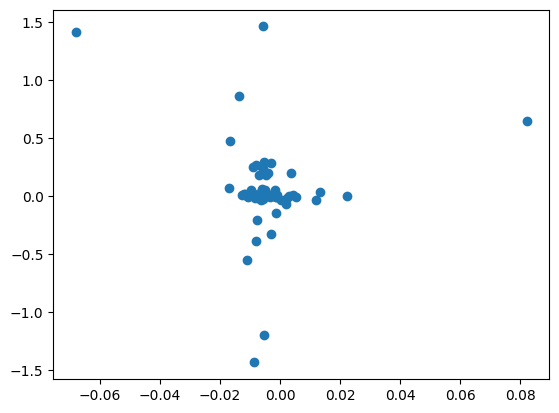

In [128]:
z = (
    data['GDPC1'].shift(2) ** 2
    - data['GDPC1'].shift(1))
y = data['FEDFUNDS'].shift(-7)
plt.scatter(z, y)
plt.show()